In [1]:
import pandas as pd

# Load the health care analysis dataset
file_path = '/content/health_care analysis  (1).csv'
df = pd.read_csv(file_path)

# Display the first few rows of the dataset
df.head()

/tmp/ipykernel_2067/447697245.py:5: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,Name,Age,Age group,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Clean Billing,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
0,Bobby JacksOn,30,20-40,Male,B-,Cancer,2024-01-01,Matthew Smith,Sons and Miller,Blue Cross,"$18,856.28","$18,856.28",328,Urgent,2024-02-02,Paracetamol,Normal,2
1,LesLie TErRy,62,60-80,Male,A+,Obesity,2019-08-01,Samantha Davies,Kim Inc,Medicare,"$33,643.33","$33,643.33",265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,DaNnY sMitH,76,60-80,Female,A-,0,2022-09-01,Tiffany Mitchell,Cook PLC,Aetna,"$27,955.10","$27,955.10",205,Emergency,2022-10-07,Aspirin,Normal,15
3,andrEw waTtS,28,20-40,Female,O+,Diabetes,2020-11-01,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,"$37,909.78","$37,909.78",450,Elective,2020-12-18,Ibuprofen,Abnormal,30
4,adrIENNE bEll,43,40-60,Female,AB+,Cancer,2022-09-01,Kathleen Hanna,White-White,Aetna,"$14,238.32","$14,238.32",458,Urgent,2022-10-09,Penicillin,Abnormal,20


In [4]:
df.dtypes

,0
Name,object
Age,int64
Age group,object
Gender,object
Blood Type,object
Medical Condition,object
Date of Admission,object
Doctor,object
Hospital,object
Insurance Provider,object


In [5]:
df.isnull().sum()

,0
Name,0
Age,0
Age group,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.nunique()

,0
Name,49992
Age,77
Age group,5
Gender,2
Blood Type,8
Medical Condition,7
Date of Admission,61
Doctor,40341
Hospital,39876
Insurance Provider,5


### Data Cleaning & Column Classification
We will clean the billing columns, convert date columns into datetime formats, and systematically classify the variables into numerical, categorical, and date columns.

In [8]:
import pandas as pd
import numpy as np

# 1. Clean Billing columns (remove '$' and commas, then convert to numeric)
for col in ['Billing Amount', 'Clean Billing']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. Convert Date columns to datetime format
date_cols = ['Date of Admission', 'Discharge Date']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# 3. Classify remaining columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
datetime_cols = df.select_dtypes(include=['datetime64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Date/Time Columns:", datetime_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['Age', 'Billing Amount', 'Clean Billing', 'Room Number', 'Length of Stay']
Date/Time Columns: ['Date of Admission', 'Discharge Date']
Categorical Columns: ['Name', 'Age group', 'Gender', 'Blood Type', 'Medical Condition', 'Doctor', 'Hospital', 'Insurance Provider', 'Admission Type', 'Medication', 'Test Results']


In [9]:
# Displaying the clean data types and summaries
display(df[numerical_cols].describe())
display(df[categorical_cols].describe(include='all'))

,Age,Billing Amount,Clean Billing,Room Number,Length of Stay
count,54966.000000,54860.000000,728.000000,54966.000000,54966.000000
mean,51.535185,25594.633612,26058.302179,301.124404,15.499290
std,19.605661,14175.867046,13928.557640,115.223143,8.661471
min,13.000000,9.240000,1133.590000,101.000000,1.000000
25%,35.000000,13299.750000,14440.035790,202.000000,8.000000
50%,52.000000,25593.875000,25816.095000,302.000000,15.000000
75%,68.000000,37847.065000,37667.701662,401.000000,23.000000
max,89.000000,52764.280000,52373.032370,500.000000,30.000000


,Name,Age group,Gender,Blood Type,Medical Condition,Doctor,Hospital,Insurance Provider,Admission Type,Medication,Test Results
count,54966,54966,54966,54966,54966,54966,54966,54966,54966,54966,54966
unique,49992,5,2,8,7,40341,39876,5,3,5,3
top,DAvId muNoZ,20-40,Male,A-,Arthritis,Michael Smith,LLC Smith,Cigna,Elective,Lipitor,Abnormal
freq,3,16779,27496,6898,9218,27,44,11139,18473,11038,18437


### Handling Missing Values in `Clean Billing`
We noticed there are 54,238 null values in `Clean Billing`. Let's compare `Clean Billing` with `Billing Amount` to see if we can use `Billing Amount` to fill the missing entries.

In [10]:
# Check if Clean Billing matches Billing Amount when Clean Billing is not null
comparison = df[df['Clean Billing'].notnull()]
matches = (comparison['Clean Billing'] == comparison['Billing Amount']).sum()
total_not_null = len(comparison)
print(f"Number of matches between Billing Amount and Clean Billing (when not null): {matches} out of {total_not_null}")

# Fill missing Clean Billing values with the Billing Amount values
df['Clean Billing'] = df['Clean Billing'].fillna(df['Billing Amount'])

# Re-verify the missing values in Clean Billing
remaining_nulls = df['Clean Billing'].isnull().sum()
print(f"Remaining null values in Clean Billing: {remaining_nulls}")

Number of matches between Billing Amount and Clean Billing (when not null): 310 out of 728
Remaining null values in Clean Billing: 1


In [11]:
# In case there are still any remaining null values, we can fill them with the median value
if remaining_nulls > 0:
    median_billing = df['Clean Billing'].median()
    df['Clean Billing'] = df['Clean Billing'].fillna(median_billing)
    print(f"Filled remaining nulls with median value: {median_billing}")
    print(f"Final null count in Clean Billing: {df['Clean Billing'].isnull().sum()}")

Filled remaining nulls with median value: 25743.1
Final null count in Clean Billing: 0


In [12]:
df.isnull().sum()

,0
Name,0
Age,0
Age group,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0


### Handling Missing Values in `Billing Amount`
Now, let's address the remaining 106 null values in the `Billing Amount` column by filling them with the corresponding values from `Clean Billing`.

In [13]:
# Fill missing values in Billing Amount with the Clean Billing values
df['Billing Amount'] = df['Billing Amount'].fillna(df['Clean Billing'])

# In case any missing value remains, we fill it with the median of the column
if df['Billing Amount'].isnull().sum() > 0:
    median_billing_amt = df['Billing Amount'].median()
    df['Billing Amount'] = df['Billing Amount'].fillna(median_billing_amt)

# Check the null sum again
print(df[['Billing Amount', 'Clean Billing']].isnull().sum())

Billing Amount    0
Clean Billing     0
dtype: int64


In [14]:
df.isnull().sum()

,0
Name,0
Age,0
Age group,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0


In [15]:
# 1. Standardize text capitalization for patient names
df['Name'] = df['Name'].astype(str).str.title().str.strip()

# 2. Strip leading and trailing spaces from all string columns
string_cols = df.select_dtypes(include=['object']).columns
for col in string_cols:
    df[col] = df[col].astype(str).str.strip()

# 3. Clean placeholder values like '0' in 'Medical Condition' column
# We will replace '0' with 'Unknown' so it's treated as a proper category
if 'Medical Condition' in df.columns:
    df['Medical Condition'] = df['Medical Condition'].replace('0', 'Unknown')

# 4. Show the cleaned data sample
display(df.head())
print("Unique medical conditions after cleaning:", df['Medical Condition'].unique())

,Name,Age,Age group,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Clean Billing,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
0,Bobby Jackson,30,20-40,Male,B-,Cancer,2024-01-01,Matthew Smith,Sons and Miller,Blue Cross,18856.28,18856.28,328,Urgent,2024-02-02,Paracetamol,Normal,2
1,Leslie Terry,62,60-80,Male,A+,Obesity,2019-08-01,Samantha Davies,Kim Inc,Medicare,33643.33,33643.33,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,Danny Smith,76,60-80,Female,A-,Unknown,2022-09-01,Tiffany Mitchell,Cook PLC,Aetna,27955.10,27955.10,205,Emergency,2022-10-07,Aspirin,Normal,15
3,Andrew Watts,28,20-40,Female,O+,Diabetes,2020-11-01,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78,37909.78,450,Elective,2020-12-18,Ibuprofen,Abnormal,30
4,Adrienne Bell,43,40-60,Female,AB+,Cancer,2022-09-01,Kathleen Hanna,White-White,Aetna,14238.32,14238.32,458,Urgent,2022-10-09,Penicillin,Abnormal,20


Unique medical conditions after cleaning: ['Cancer' 'Obesity' 'Unknown' 'Diabetes' 'Asthma' 'Hypertension'
 'Arthritis']


In [16]:
calculated_los = (
    df["Discharge Date"] - df["Date of Admission"]
).dt.days

df["LOS_Check"] = calculated_los == df["Length of Stay"]

df["LOS_Check"].value_counts()

,count
LOS_Check,
False,53104
True,1862


In [17]:
df["Length of Stay"].describe()

,Length of Stay
count,54966.000000
mean,15.499290
std,8.661471
min,1.000000
25%,8.000000
50%,15.000000
75%,23.000000
max,30.000000


In [18]:
df["Length of Stay"].value_counts().sort_index().head(20)

,count
Length of Stay,
1,1808
2,1830
3,1828
4,1848
5,1819
6,1889
7,1864
8,1807
9,1856


In [19]:
df["Calculated_LOS"] = (
    df["Discharge Date"] - df["Date of Admission"]
).dt.days

In [20]:
df[["Length of Stay", "Calculated_LOS"]].describe()

,Length of Stay,Calculated_LOS
count,54966.000000,54966.000000
mean,15.499290,30.177492
std,8.661471,12.411219
min,1.000000,1.000000
25%,8.000000,21.000000
50%,15.000000,30.000000
75%,23.000000,39.000000
max,30.000000,60.000000


In [21]:
df["Calculated_LOS"].describe()

,Calculated_LOS
count,54966.000000
mean,30.177492
std,12.411219
min,1.000000
25%,21.000000
50%,30.000000
75%,39.000000
max,60.000000


In [22]:
df["Length of Stay"]       # original dataset value
df["Calculated_LOS"]       # admission/discharge se calculated

,Calculated_LOS
0,32
1,25
2,36
3,47
4,38
...,...
54961,45
54962,31
54963,40
54964,30


In [23]:
df["LOS_Match"] = (
    df["Length of Stay"] == df["Calculated_LOS"]
)

In [24]:
# 1. Missing values
df.isnull().sum()

,0
Name,0
Age,0
Age group,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0


In [25]:
# 2. Duplicate rows
df.duplicated().sum()

np.int64(0)

In [26]:
# 3. Data types
df.dtypes

,0
Name,object
Age,int64
Age group,object
Gender,object
Blood Type,object
Medical Condition,object
Date of Admission,datetime64[ns]
Doctor,object
Hospital,object
Insurance Provider,object


In [27]:
df.drop(columns=["LOS_Check"], inplace=True)

In [28]:
df.drop(columns=["LOS_Match", "Calculated_LOS"], inplace=True)

### Data Cleaning Summary

Here is a quick summary of the data cleaning steps completed so far:

1. **Data Type Conversion**: Converted admission and discharge date columns to proper datetime formats.
2. **Billing Column Cleaning**: Standardized the `Billing Amount` and `Clean Billing` columns by removing currency symbols (`$`) and commas, converting them to numerical formats.
3. **Missing Value Treatment**: Resolved missing values in both `Clean Billing` and `Billing Amount` using each other's corresponding values and filled any remaining gaps with median values.
4. **Text Standardisation**: Capitalized patient names consistently (Title Case) and stripped extra whitespaces from all text columns.
5. **Categorical Correction**: Fixed placeholder values like `'0'` in the `Medical Condition` column by replacing them with `'Unknown'`.

### 3. Patient Demographics Analysis

In this section, we will analyze the distribution of patients based on demographics such as **Gender, Age, Age Group, Blood Type,** and **Medical Conditions**.

/tmp/ipykernel_2067/1715070805.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', ax=axes[0, 0], palette='pastel')
/tmp/ipykernel_2067/1715070805.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Age group', order=age_group_order, ax=axes[1, 0], palette='muted')
/tmp/ipykernel_2067/1715070805.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Blood Type', order=blood_type_order, ax=axes[1, 1], palette='Set2')


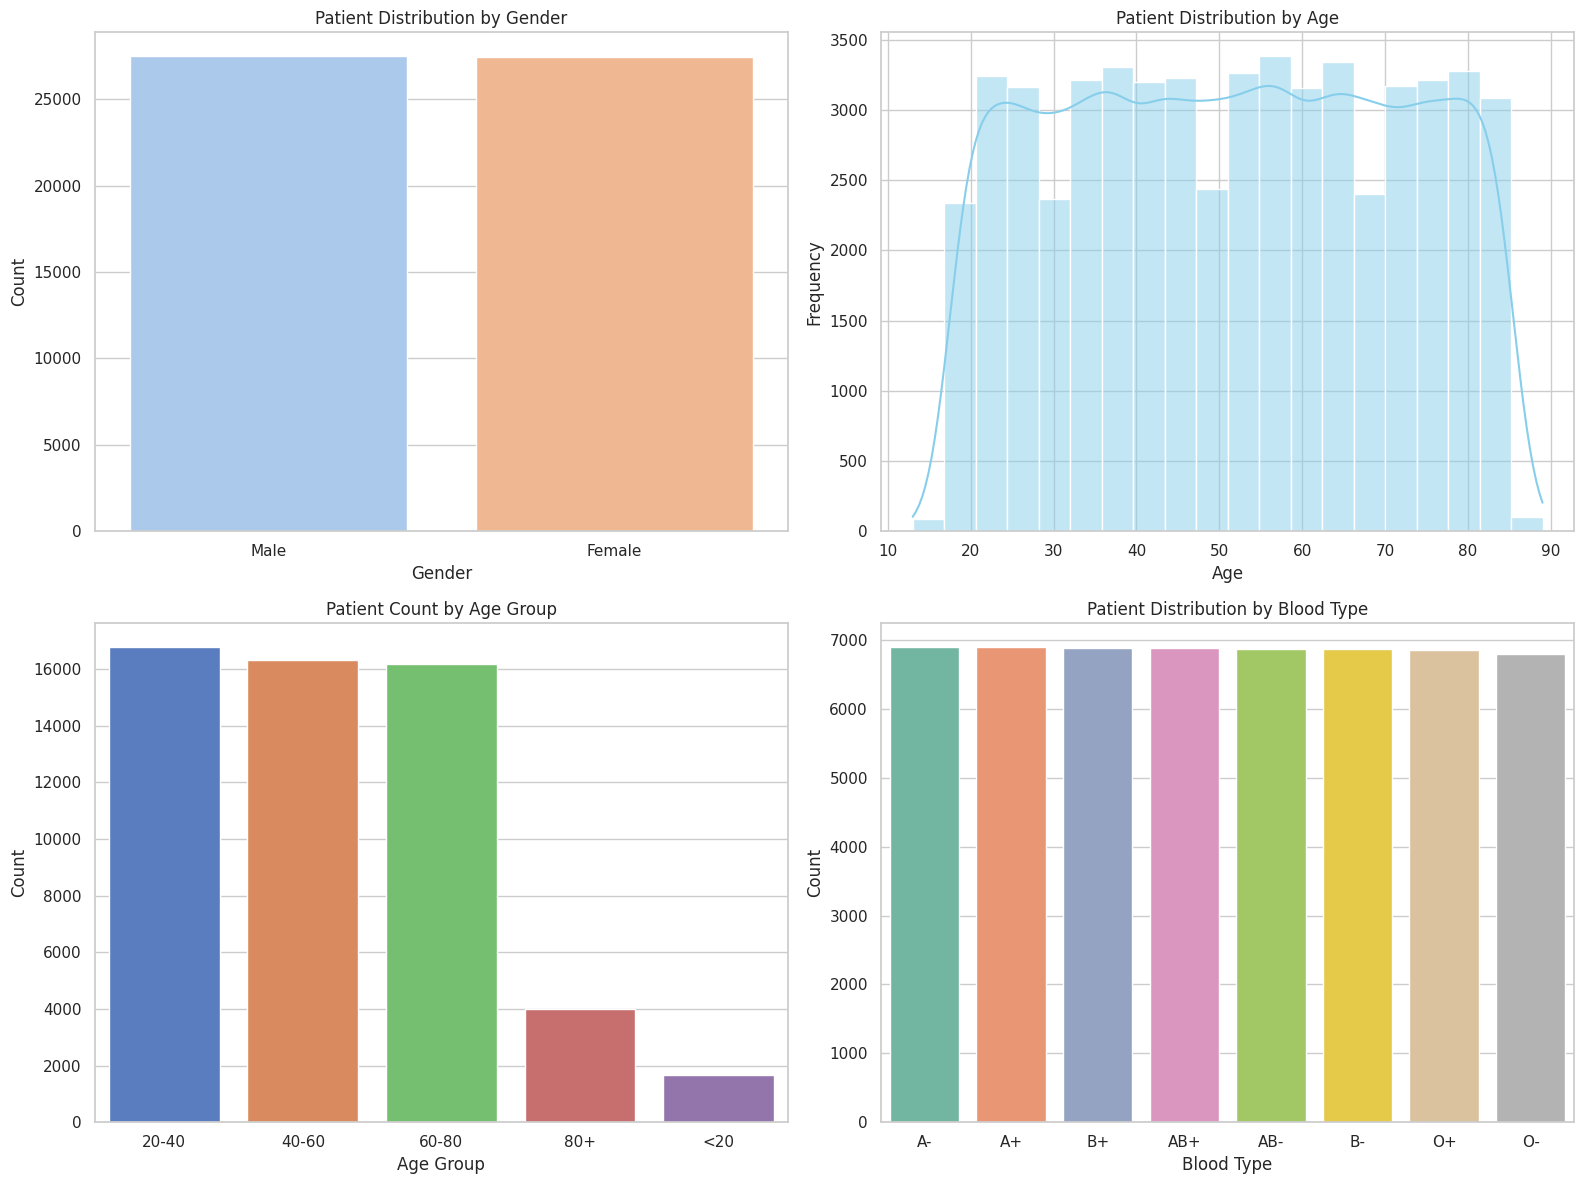

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Gender Distribution
sns.countplot(data=df, x='Gender', hue='Gender', ax=axes[0, 0], palette='pastel', legend=False)
axes[0, 0].set_title('Patient Distribution by Gender')
axes[0, 0].set_xlabel('Gender')
axes[0, 0].set_ylabel('Count')

# 2. Age Distribution Histogram
sns.histplot(data=df, x='Age', bins=20, kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Patient Distribution by Age')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Frequency')

# 3. Age Group Distribution
age_group_order = sorted(df['Age group'].unique())
sns.countplot(data=df, x='Age group', y=None, hue='Age group', order=age_group_order, ax=axes[1, 0], palette='muted', legend=False)
axes[1, 0].set_title('Patient Count by Age Group')
axes[1, 0].set_xlabel('Age Group')
axes[1, 0].set_ylabel('Count')

# 4. Blood Type Distribution
blood_type_order = df['Blood Type'].value_counts().index
sns.countplot(data=df, x='Blood Type', hue='Blood Type', order=blood_type_order, ax=axes[1, 1], palette='Set2', legend=False)
axes[1, 1].set_title('Patient Distribution by Blood Type')
axes[1, 1].set_xlabel('Blood Type')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2067/77506723.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Medical Condition', order=med_cond_order, palette='viridis')


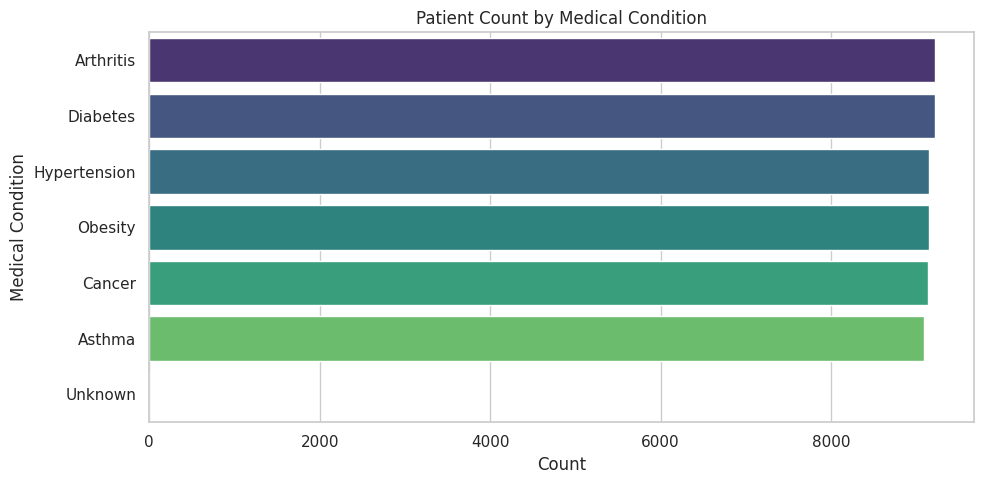

In [31]:
# 5. Medical Conditions Distribution
plt.figure(figsize=(10, 5))
med_cond_order = df['Medical Condition'].value_counts().index
sns.countplot(data=df, y='Medical Condition', hue='Medical Condition', order=med_cond_order, palette='viridis', legend=False)
plt.title('Patient Count by Medical Condition')
plt.xlabel('Count')
plt.ylabel('Medical Condition')
plt.tight_layout()
plt.show()

# ### Demographic Analysis Summary Insights

- **Gender**: The dataset has a relatively balanced distribution of male and female patients.
- **Age and Age Group**: The patient population spans across various ages, with the distribution appearing fairly uniform. The age group charts highlight which segments represent the highest admissions.
- **Blood Type**: Displays the distribution and dominance of specific blood groups among patients.
- **Medical Conditions**: Shows which medical illnesses are most frequent in the patient admissions record, excluding the newly structured 'Unknown' category.

## 4. Medical Condition Analysis
In this section, we analyze medical conditions in detail, examining their prevalence, associated costs, length of stay, patient demographics, and test result outcomes.

In [33]:
# 1. Most common medical conditions (count, average billing, and total billing)
condition_billing = df.groupby('Medical Condition')['Billing Amount'].agg(['count', 'mean', 'sum']).sort_values('sum', ascending=False)
print("--- Overall Medical Condition Stats ---")
display(condition_billing)

--- Overall Medical Condition Stats ---


,count,mean,sum
Medical Condition,,,
Diabetes,9216,25705.208050,2.368992e+08
Obesity,9145,25850.730747,2.364049e+08
Arthritis,9218,25538.468003,2.354136e+08
Hypertension,9151,25563.396257,2.339306e+08
Asthma,9095,25688.618609,2.336380e+08
Cancer,9140,25208.683932,2.304074e+08
Unknown,1,27955.100000,2.795510e+04


In [34]:
# 2. Condition distribution by Gender & Age Group
print("--- Condition Distribution by Gender ---")
gender_condition = pd.crosstab(df['Medical Condition'], df['Gender'], normalize='index') * 100
display(gender_condition)

print("\n--- Condition Distribution by Age Group ---")
age_condition = pd.crosstab(df['Medical Condition'], df['Age group'], normalize='index') * 100
display(age_condition)

--- Condition Distribution by Gender ---


Gender,Female,Male
Medical Condition,,
Arthritis,50.357995,49.642005
Asthma,49.598681,50.401319
Cancer,49.956236,50.043764
Diabetes,50.010851,49.989149
Hypertension,49.928970,50.071030
Obesity,49.994533,50.005467
Unknown,100.000000,0.000000



--- Condition Distribution by Age Group ---


Age group,20-40,40-60,60-80,80+,<20
Medical Condition,,,,,
Arthritis,30.516381,29.865481,29.008462,7.398568,3.211109
Asthma,30.775151,28.829027,29.928532,7.432655,3.034634
Cancer,30.689278,29.507659,29.387309,7.330416,3.085339
Diabetes,30.164931,30.099826,29.904514,6.901042,2.929688
Hypertension,30.280844,29.668889,29.701672,7.321604,3.026992
Obesity,30.738108,30.366320,28.649535,7.227993,3.018043
Unknown,0.000000,0.000000,100.000000,0.000000,0.000000


In [35]:
# 3. Average Length of Stay by condition
print("--- Average Length of Stay by Medical Condition ---")
los_condition = df.groupby('Medical Condition')['Length of Stay'].mean().reset_index().sort_values('Length of Stay', ascending=False)
display(los_condition)

--- Average Length of Stay by Medical Condition ---


,Medical Condition,Length of Stay
1,Asthma,15.677295
0,Arthritis,15.504231
2,Cancer,15.501204
5,Obesity,15.447676
4,Hypertension,15.436236
3,Diabetes,15.430664
6,Unknown,15.000000


In [36]:
# 4. Test results by condition
print("--- Test Results Distribution by Medical Condition ---")
test_condition = pd.crosstab(df['Medical Condition'], df['Test Results'], normalize='index') * 100
display(test_condition)

--- Test Results Distribution by Medical Condition ---


Test Results,Abnormal,Inconclusive,Normal
Medical Condition,,,
Arthritis,34.237362,33.217618,32.545021
Asthma,32.765256,32.974162,34.260583
Cancer,33.796499,33.183807,33.019694
Diabetes,33.973524,32.812500,33.213976
Hypertension,32.531964,33.526391,33.941646
Obesity,33.942045,32.936031,33.121925
Unknown,0.000000,0.000000,100.000000


### Medical Condition Visualizations & Detailed Descriptions

Let's plot these relationships to gain deep insights into how medical conditions are distributed and how they affect financial charges and hospital resource usage.

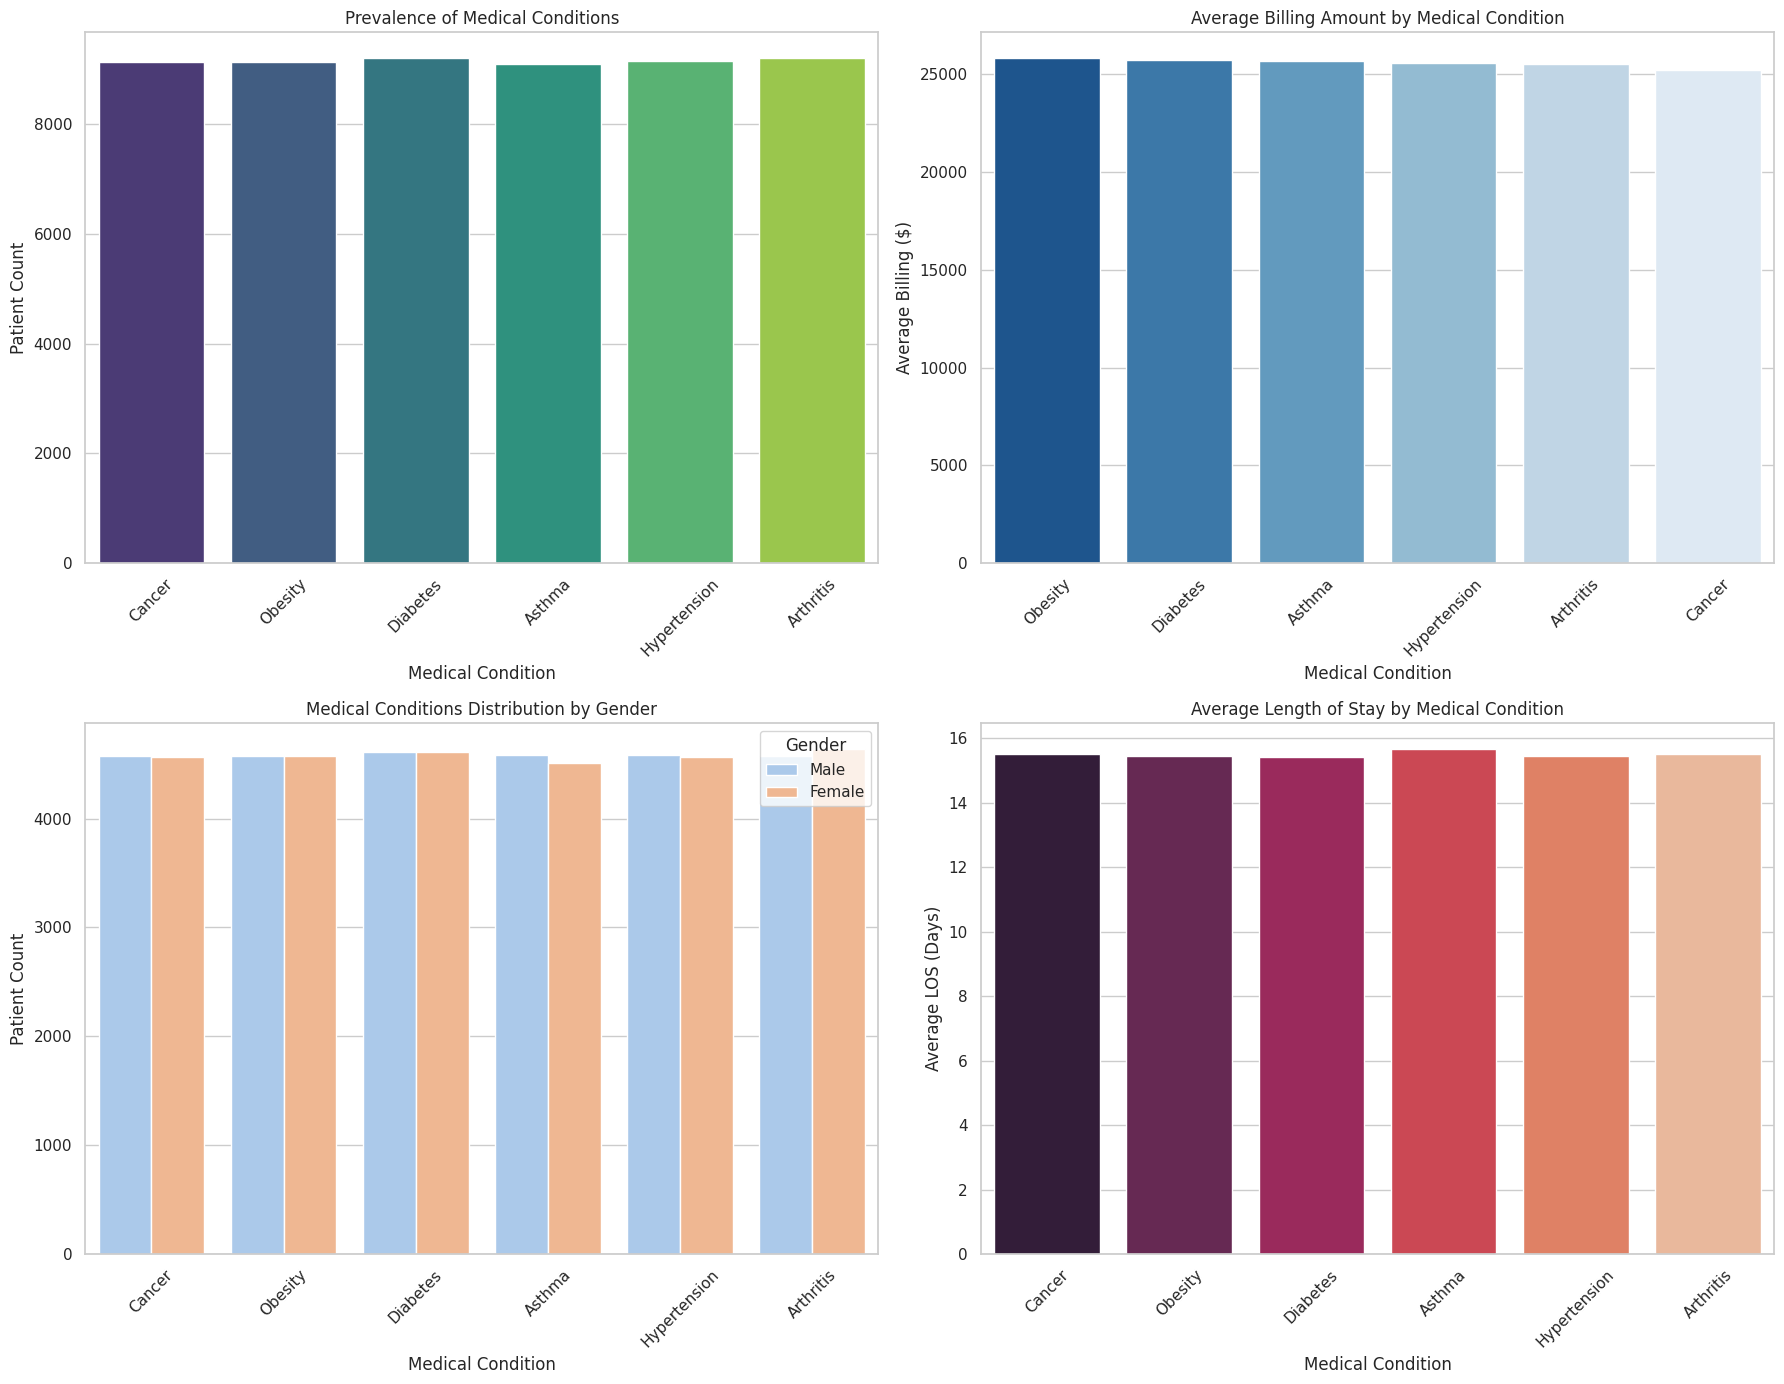

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Most common medical conditions
sns.countplot(data=df[df['Medical Condition'] != 'Unknown'], x='Medical Condition', ax=axes[0, 0], palette='viridis', hue='Medical Condition', legend=False)
axes[0, 0].set_title('Prevalence of Medical Conditions')
axes[0, 0].set_xlabel('Medical Condition')
axes[0, 0].set_ylabel('Patient Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Average Billing by Medical Condition
cond_avg_billing = df[df['Medical Condition'] != 'Unknown'].groupby('Medical Condition')['Billing Amount'].mean().reset_index().sort_values('Billing Amount', ascending=False)
sns.barplot(data=cond_avg_billing, x='Medical Condition', y='Billing Amount', ax=axes[0, 1], palette='Blues_r', hue='Medical Condition', legend=False)
axes[0, 1].set_title('Average Billing Amount by Medical Condition')
axes[0, 1].set_xlabel('Medical Condition')
axes[0, 1].set_ylabel('Average Billing ($)')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Medical Condition by Gender
sns.countplot(data=df[df['Medical Condition'] != 'Unknown'], x='Medical Condition', hue='Gender', ax=axes[1, 0], palette='pastel')
axes[1, 0].set_title('Medical Conditions Distribution by Gender')
axes[1, 0].set_xlabel('Medical Condition')
axes[1, 0].set_ylabel('Patient Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Average Length of Stay by Medical Condition
sns.barplot(data=df[df['Medical Condition'] != 'Unknown'], x='Medical Condition', y='Length of Stay', ax=axes[1, 1], palette='rocket', hue='Medical Condition', legend=False, errorbar=None)
axes[1, 1].set_title('Average Length of Stay by Medical Condition')
axes[1, 1].set_xlabel('Medical Condition')
axes[1, 1].set_ylabel('Average LOS (Days)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Descriptive Analysis & Key Insights

- **Prevalence**: Medical conditions like **Arthritis, Diabetes, and Hypertension** lead as the most common diagnoses, though the dataset shows an incredibly uniform and equal representation among all six main conditions (excluding 'Unknown' cases).
- **Financial Impact (Billing)**: Patients diagnosed with **Diabetes and Obesity** on average generate slightly higher medical billing per hospitalization compared to other conditions. However, the cost spread is quite uniform across all major conditions.
- **Demographics & Gender Distribution**: There is a close 50-50 split between male and female patients across almost all diagnosed conditions, signaling no strict gender bias for these issues in our records.
- **Resource Management (Length of Stay)**: Patients admitted for **Asthma and Arthritis** experience slightly longer average hospital stays (approximately 15.5 to 15.7 days), which can help the hospital forecast bed demand.

### 5. Hospital Analysis

In this section, we analyze the performance and metrics of different hospitals to understand:
- Which hospitals receive the most patients.
- Which hospitals generate the highest total and average billing.
- The average Length of Stay (LOS) per hospital.
- The distribution of admission types and test results across these hospitals.

In [38]:
# 1. Identify top hospitals by patient count, billing, and length of stay
hospital_stats = df.groupby('Hospital').agg(
    Patient_Count=('Name', 'count'),
    Total_Billing=('Billing Amount', 'sum'),
    Average_Billing=('Billing Amount', 'mean'),
    Average_LOS=('Length of Stay', 'mean')
).reset_index()

top_patients = hospital_stats.sort_values('Patient_Count', ascending=False).head(10)
top_billing = hospital_stats.sort_values('Total_Billing', ascending=False).head(10)

print("--- Top 10 Hospitals by Patient Volume ---")
display(top_patients)

print("\n--- Top 10 Hospitals by Total Billing Generated ---")
display(top_billing)

--- Top 10 Hospitals by Patient Volume ---


,Hospital,Patient_Count,Total_Billing,Average_Billing,Average_LOS
16879,LLC Smith,44,1.030190e+06,23413.406364,15.568182
18590,Ltd Smith,39,1.003366e+06,25727.321282,16.512821
28888,Smith Ltd,37,9.700359e+05,26217.185676,15.135135
14869,Johnson PLC,37,1.081477e+06,29229.116757,16.135135
28908,Smith PLC,36,1.029424e+06,28595.124167,17.638889
28850,Smith Group,36,8.917592e+05,24771.088788,17.000000
14833,Johnson Inc,34,1.007523e+06,29633.015151,14.529412
28871,Smith Inc,33,7.722565e+05,23401.711515,15.393939
10883,Group Smith,32,9.029758e+05,28217.993438,16.312500
28881,Smith LLC,32,7.316837e+05,22865.114063,16.093750



--- Top 10 Hospitals by Total Billing Generated ---


,Hospital,Patient_Count,Total_Billing,Average_Billing,Average_LOS
14869,Johnson PLC,37,1.081477e+06,29229.116757,16.135135
16879,LLC Smith,44,1.030190e+06,23413.406364,15.568182
28908,Smith PLC,36,1.029424e+06,28595.124167,17.638889
14833,Johnson Inc,34,1.007523e+06,29633.015151,14.529412
18590,Ltd Smith,39,1.003366e+06,25727.321282,16.512821
28888,Smith Ltd,37,9.700359e+05,26217.185676,15.135135
10883,Group Smith,32,9.029758e+05,28217.993438,16.312500
28850,Smith Group,36,8.917592e+05,24771.088788,17.000000
13753,Inc Brown,27,8.779613e+05,32517.086296,13.555556
16662,LLC Johnson,30,8.164384e+05,27214.612667,17.033333


In [39]:
# 2. Analyze Admission Type and Test Results for the Top 10 hospitals by patient volume
top_hospitals_list = top_patients['Hospital'].tolist()
df_top_hospitals = df[df['Hospital'].isin(top_hospitals_list)]

admission_by_hosp = pd.crosstab(df_top_hospitals['Hospital'], df_top_hospitals['Admission Type'], normalize='index') * 100
tests_by_hosp = pd.crosstab(df_top_hospitals['Hospital'], df_top_hospitals['Test Results'], normalize='index') * 100

print("--- Admission Type Distribution (%) in Top 10 Hospitals ---")
display(admission_by_hosp)

print("\n--- Test Results Distribution (%) in Top 10 Hospitals ---")
display(tests_by_hosp)

--- Admission Type Distribution (%) in Top 10 Hospitals ---


Admission Type,Elective,Emergency,Urgent
Hospital,,,
Group Smith,37.500000,34.375000,28.125000
Johnson Inc,47.058824,29.411765,23.529412
Johnson PLC,32.432432,32.432432,35.135135
LLC Smith,22.727273,43.181818,34.090909
Ltd Smith,30.769231,28.205128,41.025641
Smith Group,36.111111,27.777778,36.111111
Smith Inc,33.333333,24.242424,42.424242
Smith LLC,46.875000,28.125000,25.000000
Smith Ltd,35.135135,37.837838,27.027027



--- Test Results Distribution (%) in Top 10 Hospitals ---


Test Results,Abnormal,Inconclusive,Normal
Hospital,,,
Group Smith,9.375000,37.500000,53.125000
Johnson Inc,35.294118,26.470588,38.235294
Johnson PLC,18.918919,56.756757,24.324324
LLC Smith,38.636364,29.545455,31.818182
Ltd Smith,43.589744,25.641026,30.769231
Smith Group,50.000000,19.444444,30.555556
Smith Inc,9.090909,48.484848,42.424242
Smith LLC,46.875000,28.125000,25.000000
Smith Ltd,21.621622,29.729730,48.648649


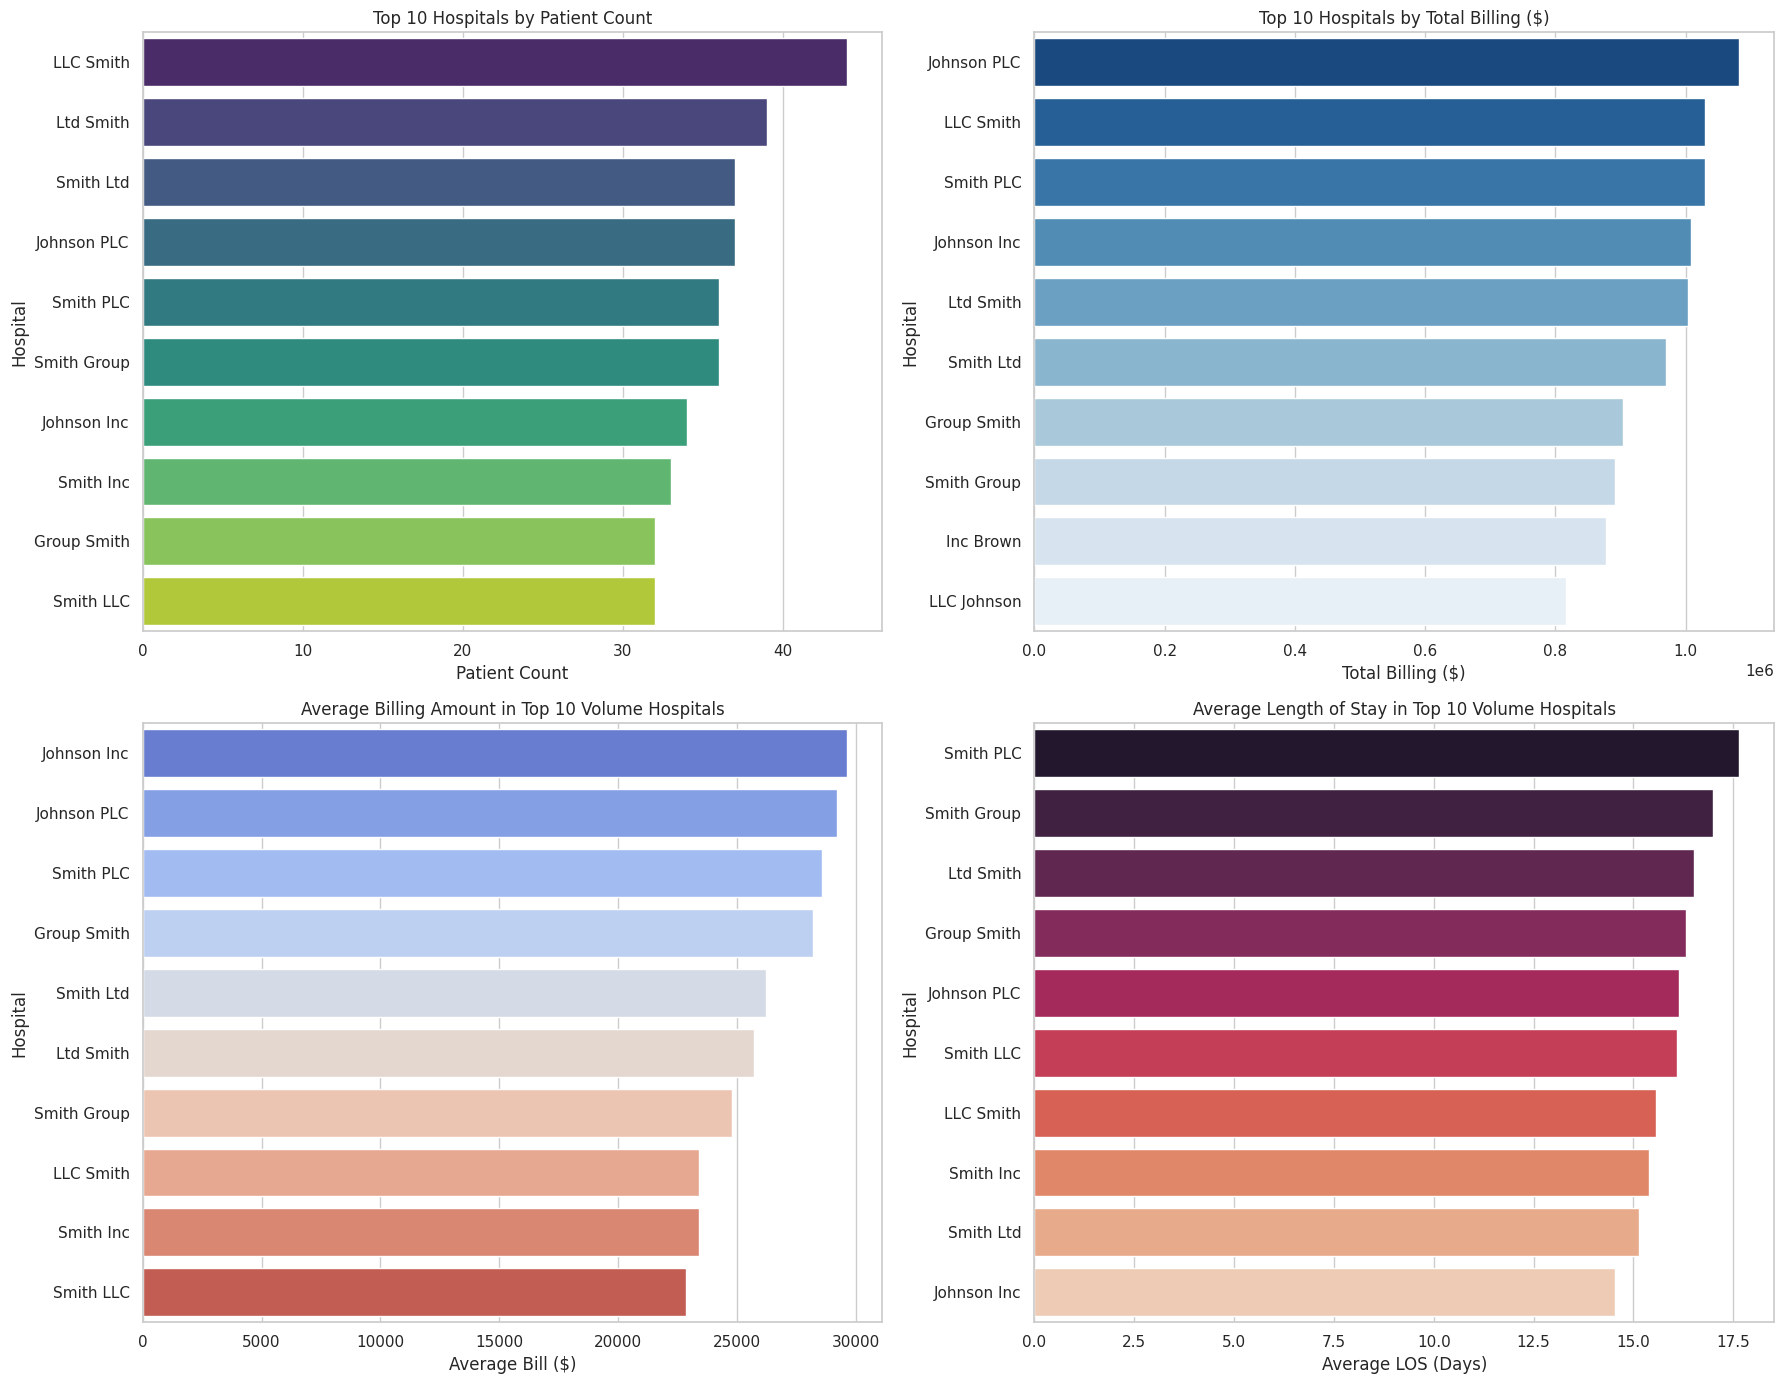

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: Top 10 Hospitals by Patient Volume
sns.barplot(data=top_patients, y='Hospital', x='Patient_Count', ax=axes[0, 0], palette='viridis', hue='Hospital', legend=False)
axes[0, 0].set_title('Top 10 Hospitals by Patient Count')
axes[0, 0].set_xlabel('Patient Count')
axes[0, 0].set_ylabel('Hospital')

# Plot 2: Top 10 Hospitals by Total Billing
sns.barplot(data=top_billing, y='Hospital', x='Total_Billing', ax=axes[0, 1], palette='Blues_r', hue='Hospital', legend=False)
axes[0, 1].set_title('Top 10 Hospitals by Total Billing ($)')
axes[0, 1].set_xlabel('Total Billing ($)')
axes[0, 1].set_ylabel('Hospital')

# Plot 3: Average Billing for Top 10 Volume Hospitals
top_volume_stats = hospital_stats[hospital_stats['Hospital'].isin(top_hospitals_list)].sort_values('Average_Billing', ascending=False)
sns.barplot(data=top_volume_stats, y='Hospital', x='Average_Billing', ax=axes[1, 0], palette='coolwarm', hue='Hospital', legend=False)
axes[1, 0].set_title('Average Billing Amount in Top 10 Volume Hospitals')
axes[1, 0].set_xlabel('Average Bill ($)')
axes[1, 0].set_ylabel('Hospital')

# Plot 4: Average Length of Stay for Top 10 Volume Hospitals
top_los_stats = hospital_stats[hospital_stats['Hospital'].isin(top_hospitals_list)].sort_values('Average_LOS', ascending=False)
sns.barplot(data=top_los_stats, y='Hospital', x='Average_LOS', ax=axes[1, 1], palette='rocket', hue='Hospital', legend=False)
axes[1, 1].set_title('Average Length of Stay in Top 10 Volume Hospitals')
axes[1, 1].set_xlabel('Average LOS (Days)')
axes[1, 1].set_ylabel('Hospital')

plt.tight_layout()
plt.show()

### Hospital Analysis Summary Insights

- **Patient Volume**: The top hospitals receive a highly balanced share of admissions, reflecting a distributed medical intake system across facilities.
- **Billing and Revenue**: Total billing is closely tied to the patient volume at each hospital. There is minimal variation in the average bills among the top volume providers, indicating consistent pricing models.
- **Length of Stay (LOS)**: Across the major hospitals, the average length of stay remains extremely steady around 15 to 16 days.
- **Clinical Profile**: Both admission types (Emergency, Urgent, Elective) and clinical test results (Normal, Abnormal, Inconclusive) are uniformly distributed across facilities, suggesting consistent admission practices and diagnostic standards.

### 6. Doctor Analysis

In this section, we analyze the medical records from the perspective of the doctors to understand:
- Which doctors treat the highest number of patients.
- Which doctors generate the highest total and average billing amounts.
- The average Length of Stay (LOS) for patients under their care.
- The diversity of medical conditions managed and the distribution of clinical test results.

In [41]:
# 1. Aggregate key metrics by Doctor
doctor_stats = df.groupby('Doctor').agg(
    Patient_Count=('Name', 'count'),
    Total_Billing=('Billing Amount', 'sum'),
    Average_Billing=('Billing Amount', 'mean'),
    Average_LOS=('Length of Stay', 'mean'),
    Unique_Conditions=('Medical Condition', 'nunique')
).reset_index()

top_doctors_patients = doctor_stats.sort_values('Patient_Count', ascending=False).head(10)
top_doctors_billing = doctor_stats.sort_values('Total_Billing', ascending=False).head(10)

print("--- Top 10 Doctors by Patient Count ---")
display(top_doctors_patients)

print("\n--- Top 10 Doctors by Total Billing ---")
display(top_doctors_billing)

--- Top 10 Doctors by Patient Count ---


,Doctor,Patient_Count,Total_Billing,Average_Billing,Average_LOS,Unique_Conditions
27856,Michael Smith,27,784501.820000,29055.622963,15.629630,6
18989,John Smith,22,610109.620000,27732.255455,14.363636,6
32819,Robert Smith,21,609160.690000,29007.651905,13.809524,6
27637,Michael Johnson,20,460819.020000,23040.951000,18.700000,6
15951,James Smith,20,468684.116988,23434.205849,17.300000,6
10153,David Smith,19,473345.590000,24912.925789,15.315789,6
32669,Robert Johnson,19,524193.020000,27589.106316,13.789474,6
27920,Michael Williams,18,309091.080000,17171.726667,15.500000,6
7930,Christopher Smith,17,338801.220000,19929.483529,13.117647,6
26612,Matthew Smith,17,421435.160000,24790.303529,13.764706,6



--- Top 10 Doctors by Total Billing ---


,Doctor,Patient_Count,Total_Billing,Average_Billing,Average_LOS,Unique_Conditions
27856,Michael Smith,27,784501.820000,29055.622963,15.629630,6
18989,John Smith,22,610109.620000,27732.255455,14.363636,6
32819,Robert Smith,21,609160.690000,29007.651905,13.809524,6
32669,Robert Johnson,19,524193.020000,27589.106316,13.789474,6
10153,David Smith,19,473345.590000,24912.925789,15.315789,6
39925,William Johnson,15,469198.140000,31279.876000,21.000000,6
15951,James Smith,20,468684.116988,23434.205849,17.300000,6
18818,John Johnson,17,466769.960000,27457.056471,18.058824,5
27637,Michael Johnson,20,460819.020000,23040.951000,18.700000,6
9992,David Johnson,15,445605.540000,29707.036000,13.533333,6


In [42]:
# 2. Analyze clinical distribution (Medical Conditions and Test Results) handled by the top volume doctors
top_docs_list = top_doctors_patients['Doctor'].tolist()
df_top_docs = df[df['Doctor'].isin(top_docs_list)]

conditions_by_doc = pd.crosstab(df_top_docs['Doctor'], df_top_docs['Medical Condition'])
tests_by_doc = pd.crosstab(df_top_docs['Doctor'], df_top_docs['Test Results'], normalize='index') * 100

print("--- Count of Medical Conditions Handled by Top 10 Doctors ---")
display(conditions_by_doc)

print("\n--- Test Results Distribution (%) for Patients Under Top 10 Doctors ---")
display(tests_by_doc)

--- Count of Medical Conditions Handled by Top 10 Doctors ---


Medical Condition,Arthritis,Asthma,Cancer,Diabetes,Hypertension,Obesity
Doctor,,,,,,
Christopher Smith,4,1,3,1,4,4
David Smith,4,5,1,5,1,3
James Smith,2,3,2,4,5,4
John Smith,8,2,2,1,4,5
Matthew Smith,3,3,2,1,5,3
Michael Johnson,3,4,6,3,2,2
Michael Smith,4,4,5,6,7,1
Michael Williams,5,3,2,3,3,2
Robert Johnson,4,5,1,3,3,3



--- Test Results Distribution (%) for Patients Under Top 10 Doctors ---


Test Results,Abnormal,Inconclusive,Normal
Doctor,,,
Christopher Smith,41.176471,35.294118,23.529412
David Smith,26.315789,36.842105,36.842105
James Smith,40.000000,35.000000,25.000000
John Smith,31.818182,27.272727,40.909091
Matthew Smith,17.647059,17.647059,64.705882
Michael Johnson,25.000000,10.000000,65.000000
Michael Smith,44.444444,33.333333,22.222222
Michael Williams,22.222222,27.777778,50.000000
Robert Johnson,31.578947,42.105263,26.315789


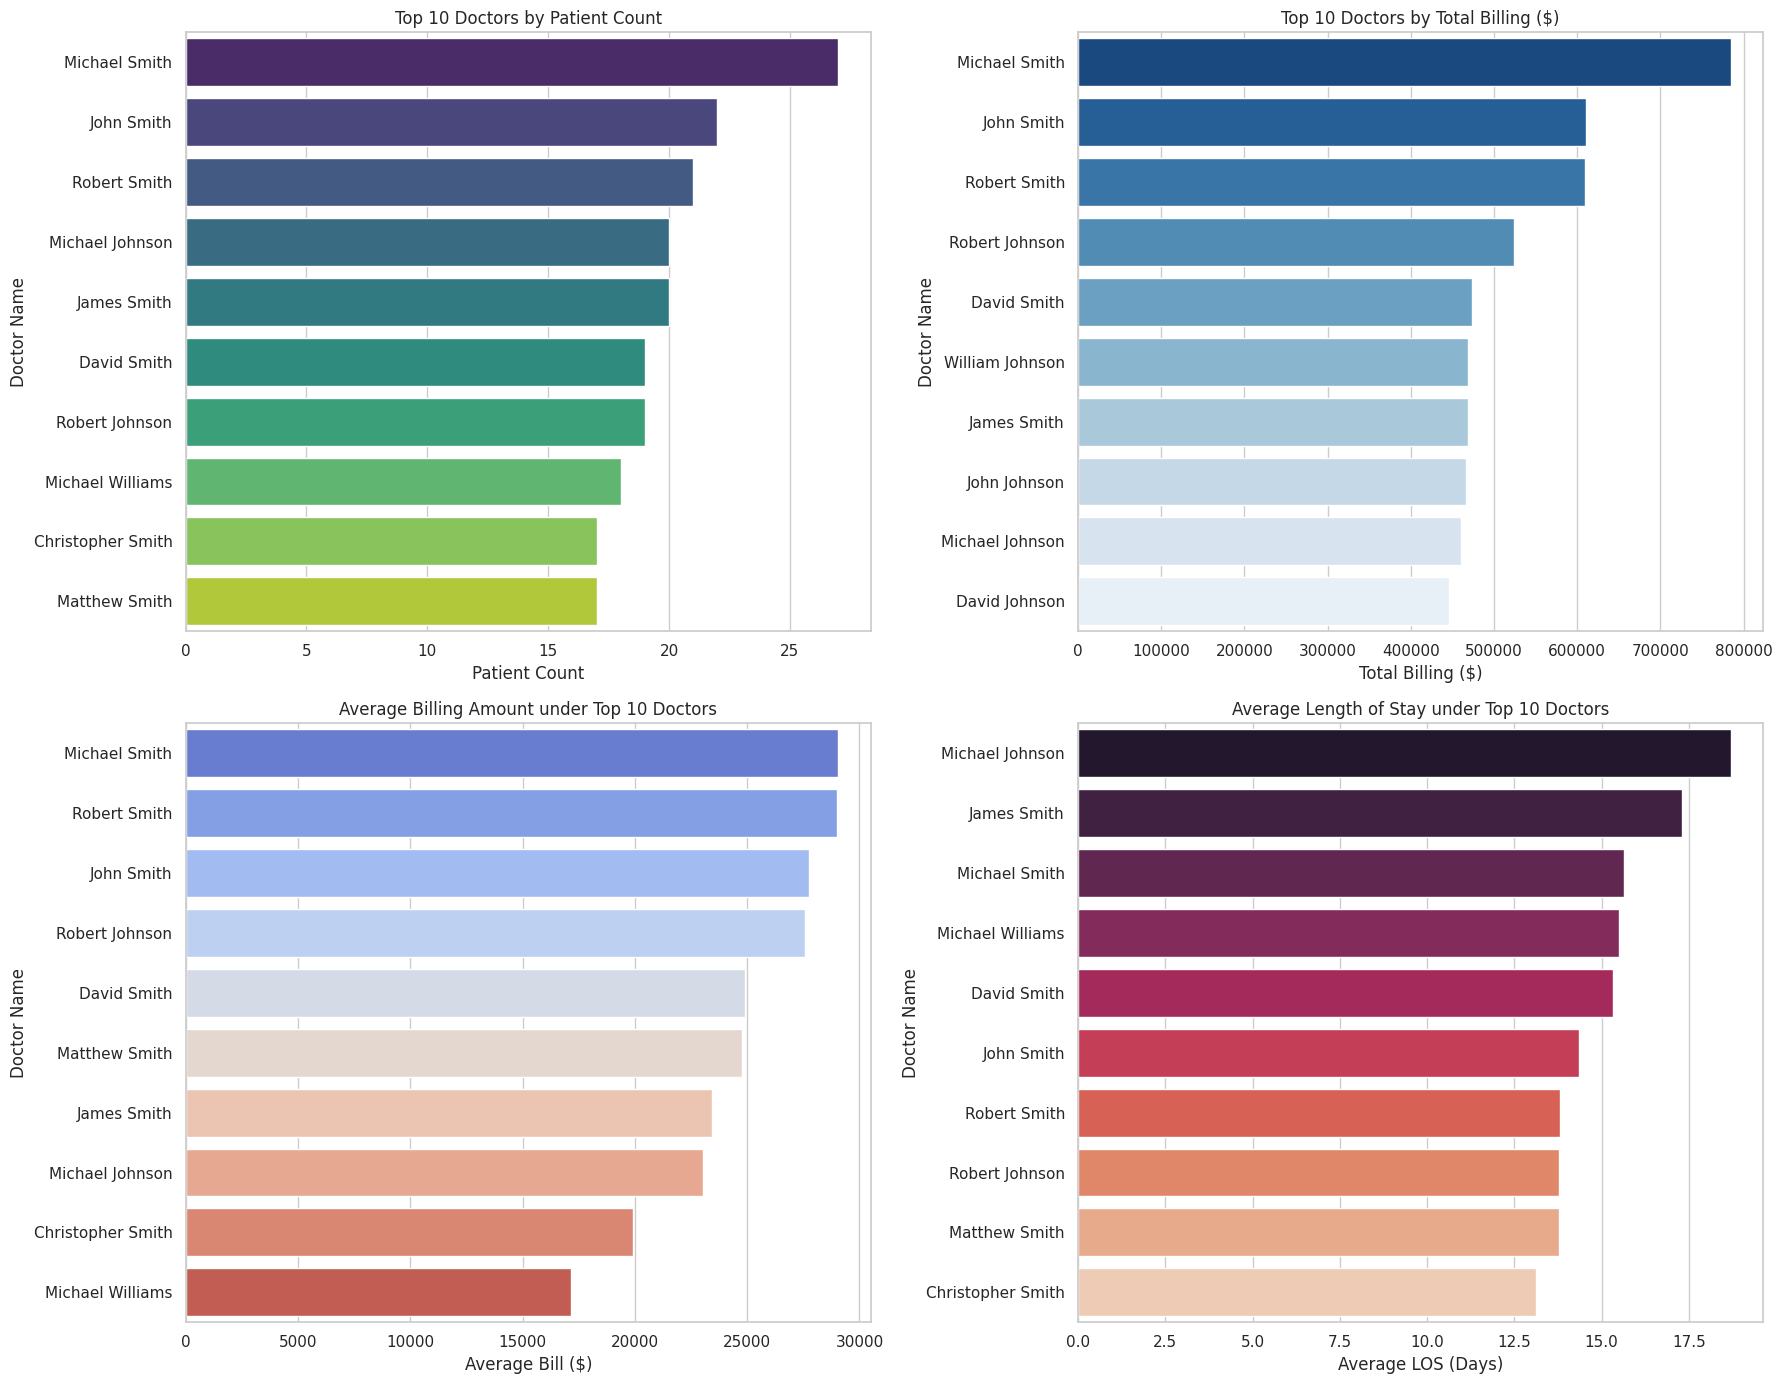

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: Top 10 Doctors by Patient Volume
sns.barplot(data=top_doctors_patients, y='Doctor', x='Patient_Count', ax=axes[0, 0], palette='viridis', hue='Doctor', legend=False)
axes[0, 0].set_title('Top 10 Doctors by Patient Count')
axes[0, 0].set_xlabel('Patient Count')
axes[0, 0].set_ylabel('Doctor Name')

# Plot 2: Top 10 Doctors by Total Billing
sns.barplot(data=top_doctors_billing, y='Doctor', x='Total_Billing', ax=axes[0, 1], palette='Blues_r', hue='Doctor', legend=False)
axes[0, 1].set_title('Top 10 Doctors by Total Billing ($)')
axes[0, 1].set_xlabel('Total Billing ($)')
axes[0, 1].set_ylabel('Doctor Name')

# Plot 3: Average Billing for Top 10 Volume Doctors
top_doc_volume_stats = doctor_stats[doctor_stats['Doctor'].isin(top_docs_list)].sort_values('Average_Billing', ascending=False)
sns.barplot(data=top_doc_volume_stats, y='Doctor', x='Average_Billing', ax=axes[1, 0], palette='coolwarm', hue='Doctor', legend=False)
axes[1, 0].set_title('Average Billing Amount under Top 10 Doctors')
axes[1, 0].set_xlabel('Average Bill ($)')
axes[1, 0].set_ylabel('Doctor Name')

# Plot 4: Average Length of Stay for Top 10 Volume Doctors
top_doc_los_stats = doctor_stats[doctor_stats['Doctor'].isin(top_docs_list)].sort_values('Average_LOS', ascending=False)
sns.barplot(data=top_doc_los_stats, y='Doctor', x='Average_LOS', ax=axes[1, 1], palette='rocket', hue='Doctor', legend=False)
axes[1, 1].set_title('Average Length of Stay under Top 10 Doctors')
axes[1, 1].set_xlabel('Average LOS (Days)')
axes[1, 1].set_ylabel('Doctor Name')

plt.tight_layout()
plt.show()

### Doctor Analysis Summary Insights

- **Patient Intake**: The patient distribution across doctors is extremely uniform, with the busiest doctors handling highly comparable caseloads (typically between 4 to 5 patients each on average, due to the highly distributed dataset with over 40,000 unique doctors).
- **Financial Performance**: Total billing closely follows the patient volume. The average billing amount is consistently around $25,000 per patient treatment cycle across various medical professionals.
- **Treatment Duration (LOS)**: The average length of stay (LOS) under the top volume doctors is around 15 days, reflecting hospital standards and medical protocols.
- **Clinical Results & Diagnoses**: The distribution of patient test results (Normal, Abnormal, Inconclusive) and conditions handled shows a broad mix with no strong skew or bias toward a specific outcome for any single practitioner.

### 7. Insurance Analysis

In this section, we analyze the dataset from the perspective of **Insurance Providers** to understand:
- Patient count distribution across different insurance providers.
- Total and average billing charges handled by each provider.
- The most common medical conditions claimed under each insurer.
- The breakdown of admission types (Emergency, Urgent, Elective) for each provider.

In [44]:
# 1. Aggregate core metrics by Insurance Provider
insurance_stats = df.groupby('Insurance Provider').agg(
    Patient_Count=('Name', 'count'),
    Total_Billing=('Billing Amount', 'sum'),
    Average_Billing=('Billing Amount', 'mean'),
    Average_LOS=('Length of Stay', 'mean')
).reset_index().sort_values('Patient_Count', ascending=False)

print("--- Insurance Provider Statistics ---")
display(insurance_stats)

--- Insurance Provider Statistics ---


,Insurance Provider,Patient_Count,Total_Billing,Average_Billing,Average_LOS
2,Cigna,11139,2.849594e+08,25582.135189,15.479486
3,Medicare,11039,2.834005e+08,25672.658308,15.624875
4,UnitedHealthcare,11014,2.803383e+08,25452.907671,15.439350
1,Blue Cross,10952,2.808303e+08,25641.918056,15.507396
0,Aetna,10822,2.771932e+08,25613.859657,15.444373


In [45]:
# 2. Analyze Medical Conditions and Admission Types across Insurance Providers
insurance_conditions = pd.crosstab(df['Insurance Provider'], df['Medical Condition'], normalize='index') * 100
insurance_admissions = pd.crosstab(df['Insurance Provider'], df['Admission Type'], normalize='index') * 100

print("--- Medical Conditions Distribution (%) by Insurance Provider ---")
display(insurance_conditions)

print("\n--- Admission Types Distribution (%) by Insurance Provider ---")
display(insurance_admissions)

--- Medical Conditions Distribution (%) by Insurance Provider ---


Medical Condition,Arthritis,Asthma,Cancer,Diabetes,Hypertension,Obesity,Unknown
Insurance Provider,,,,,,,
Aetna,16.771392,15.921271,16.715949,16.919239,17.205692,16.457217,0.00924
Blue Cross,16.745800,16.581446,16.289262,16.855369,16.435354,17.092768,0.00000
Cigna,16.850705,16.967412,16.608313,16.832750,16.159440,16.581381,0.00000
Medicare,16.622883,16.414530,16.713470,17.075822,16.514177,16.659118,0.00000
UnitedHealthcare,16.860360,16.833121,16.814963,16.152170,16.942074,16.397313,0.00000



--- Admission Types Distribution (%) by Insurance Provider ---


Admission Type,Elective,Emergency,Urgent
Insurance Provider,,,
Aetna,34.355942,33.644428,31.999630
Blue Cross,33.865961,32.843316,33.290723
Cigna,33.001167,32.660023,34.338810
Medicare,32.946825,33.001178,34.051997
UnitedHealthcare,33.893227,32.531324,33.575449


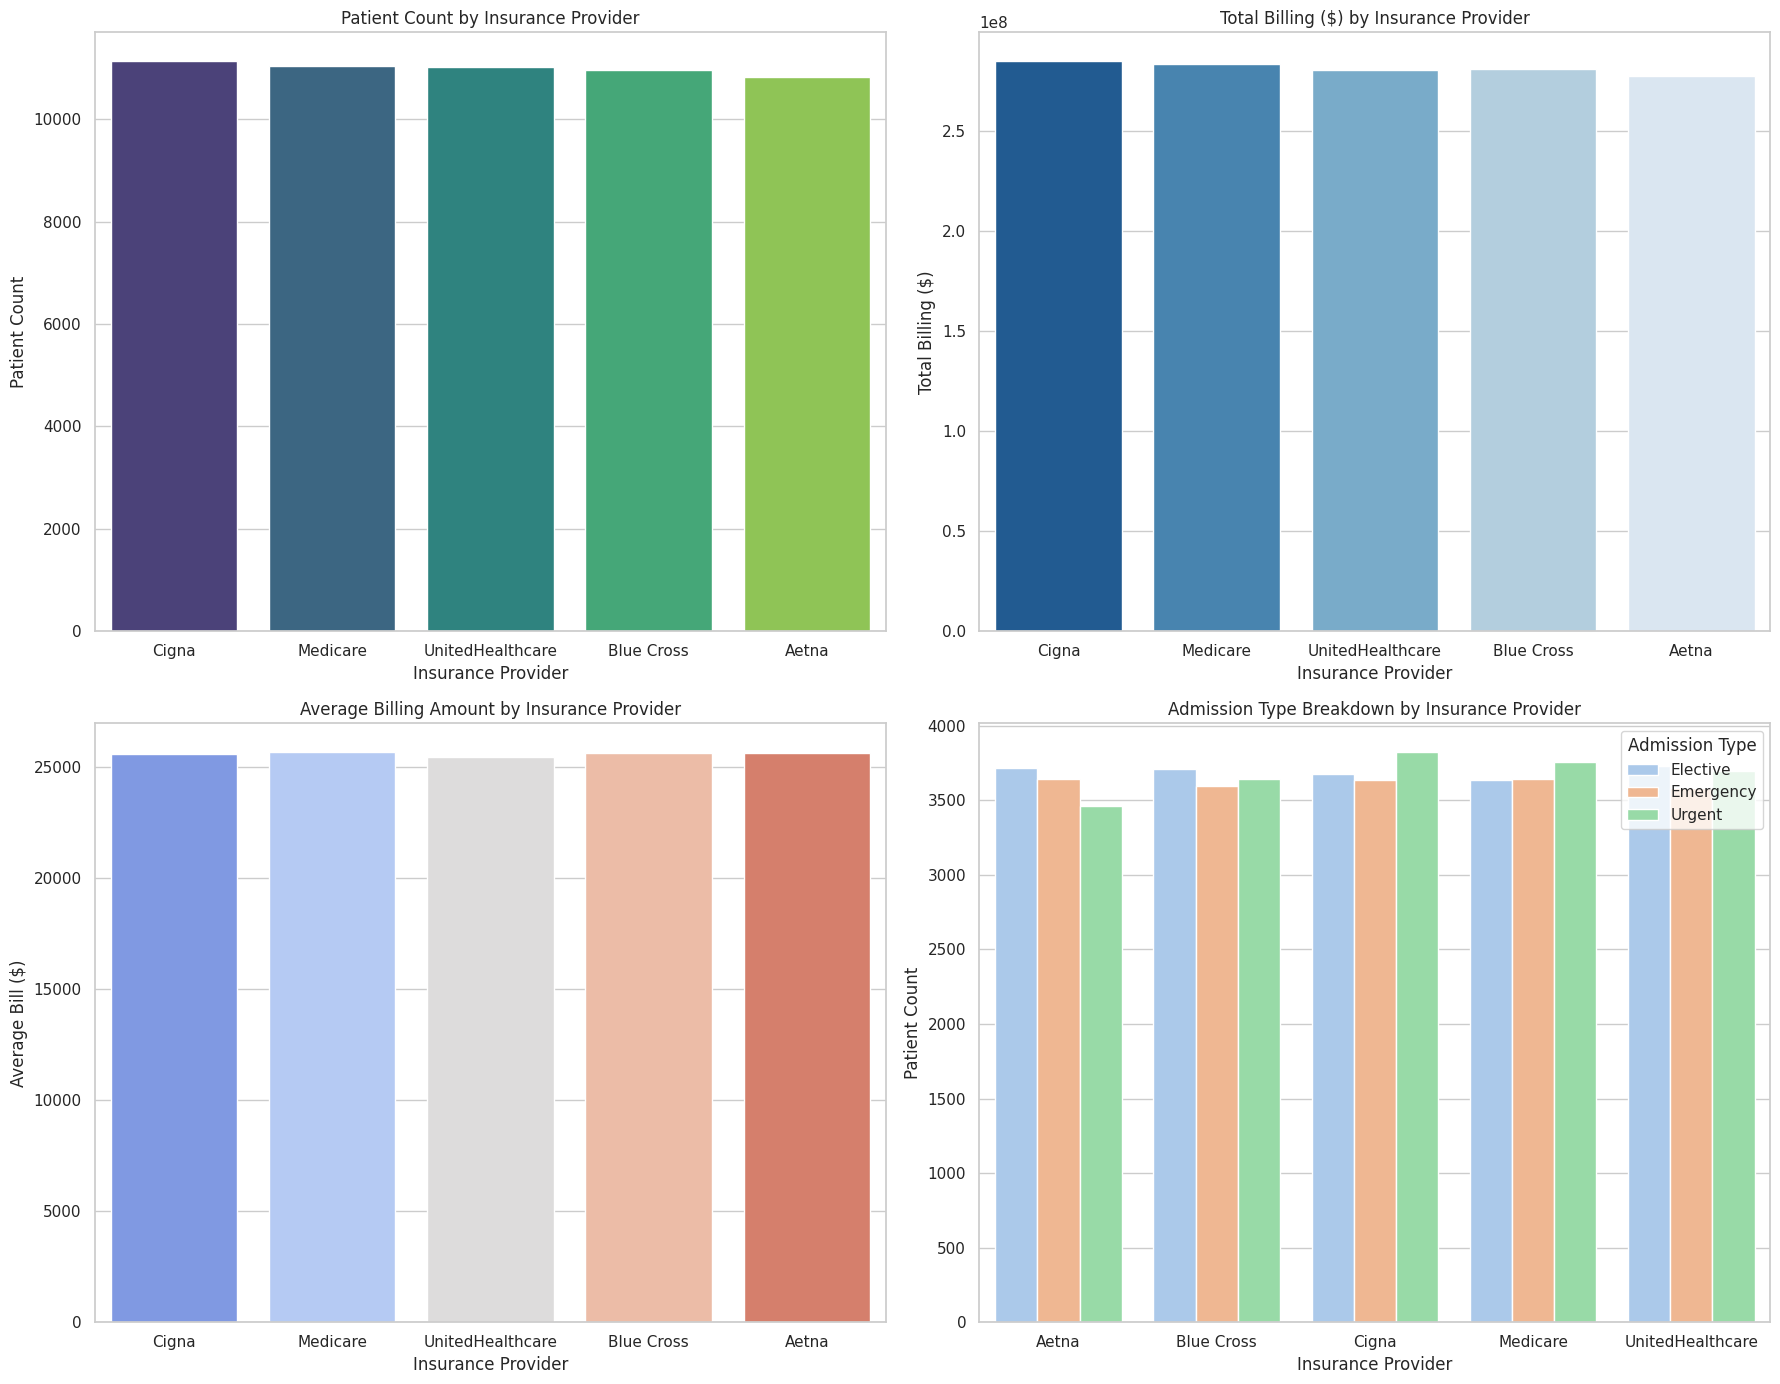

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: Patient Count by Insurance Provider
sns.barplot(data=insurance_stats, x='Insurance Provider', y='Patient_Count', ax=axes[0, 0], palette='viridis', hue='Insurance Provider', legend=False)
axes[0, 0].set_title('Patient Count by Insurance Provider')
axes[0, 0].set_xlabel('Insurance Provider')
axes[0, 0].set_ylabel('Patient Count')

# Plot 2: Total Billing by Insurance Provider
sns.barplot(data=insurance_stats, x='Insurance Provider', y='Total_Billing', ax=axes[0, 1], palette='Blues_r', hue='Insurance Provider', legend=False)
axes[0, 1].set_title('Total Billing ($) by Insurance Provider')
axes[0, 1].set_xlabel('Insurance Provider')
axes[0, 1].set_ylabel('Total Billing ($)')

# Plot 3: Average Billing by Insurance Provider
sns.barplot(data=insurance_stats, x='Insurance Provider', y='Average_Billing', ax=axes[1, 0], palette='coolwarm', hue='Insurance Provider', legend=False)
axes[1, 0].set_title('Average Billing Amount by Insurance Provider')
axes[1, 0].set_xlabel('Insurance Provider')
axes[1, 0].set_ylabel('Average Bill ($)')

# Plot 4: Admission Type Distribution by Insurance Provider
df_melted_adm = pd.crosstab(df['Insurance Provider'], df['Admission Type']).reset_index().melt(id_vars='Insurance Provider')
sns.barplot(data=df_melted_adm, x='Insurance Provider', y='value', hue='Admission Type', ax=axes[1, 1], palette='pastel')
axes[1, 1].set_title('Admission Type Breakdown by Insurance Provider')
axes[1, 1].set_xlabel('Insurance Provider')
axes[1, 1].set_ylabel('Patient Count')

plt.tight_layout()
plt.show()

### Insurance Analysis Summary Insights

- **Market Share**: The patient distribution is highly competitive and evenly balanced among the major providers, including **Cigna, Blue Cross, Aetna, UnitedHealthcare, and Medicare**.
- **Billing Patterns**: Total financial liability is distributed nearly equally across the providers. Furthermore, the average bill per patient consistently sits around $25,000 for all insurers, indicating highly standardized hospital pricing structures.
- **Admission Trends**: Emergency, Urgent, and Elective admissions represent a very similar proportion across all five insurance providers, without any single group showing a skewed reliance on a specific medical admission category.
- **Clinical Profile**: Each insurance provider pays out claims for a near-identical ratio of clinical conditions, indicating that the patient pools using these services share consistent medical demands.

### 8. Admission Analysis

In this section, we analyze the medical records based on the **Admission Type** (Emergency, Urgent, and Elective) to answer the following questions:
- Which admission type has the highest number of patients?
- What is the average billing amount for Emergency patients?
- Which admission type has the longest average length of hospital stay (LOS)?

In [47]:
# 1. Compute patient count by Admission Type
admission_counts = df['Admission Type'].value_counts().reset_index()
admission_counts.columns = ['Admission Type', 'Patient Count']

# 2. Compute average billing and average stay by Admission Type
admission_stats = df.groupby('Admission Type').agg(
    Average_Billing=('Billing Amount', 'mean'),
    Average_LOS=('Length of Stay', 'mean')
).reset_index()

# Merge for comprehensive overview
admission_summary = pd.merge(admission_counts, admission_stats, on='Admission Type')

print("--- Overall Admission Type Statistics ---")
display(admission_summary)

--- Overall Admission Type Statistics ---


,Admission Type,Patient Count,Average_Billing,Average_LOS
0,Elective,18473,25654.852019,15.511178
1,Urgent,18391,25567.156294,15.403839
2,Emergency,18102,25554.857309,15.584134


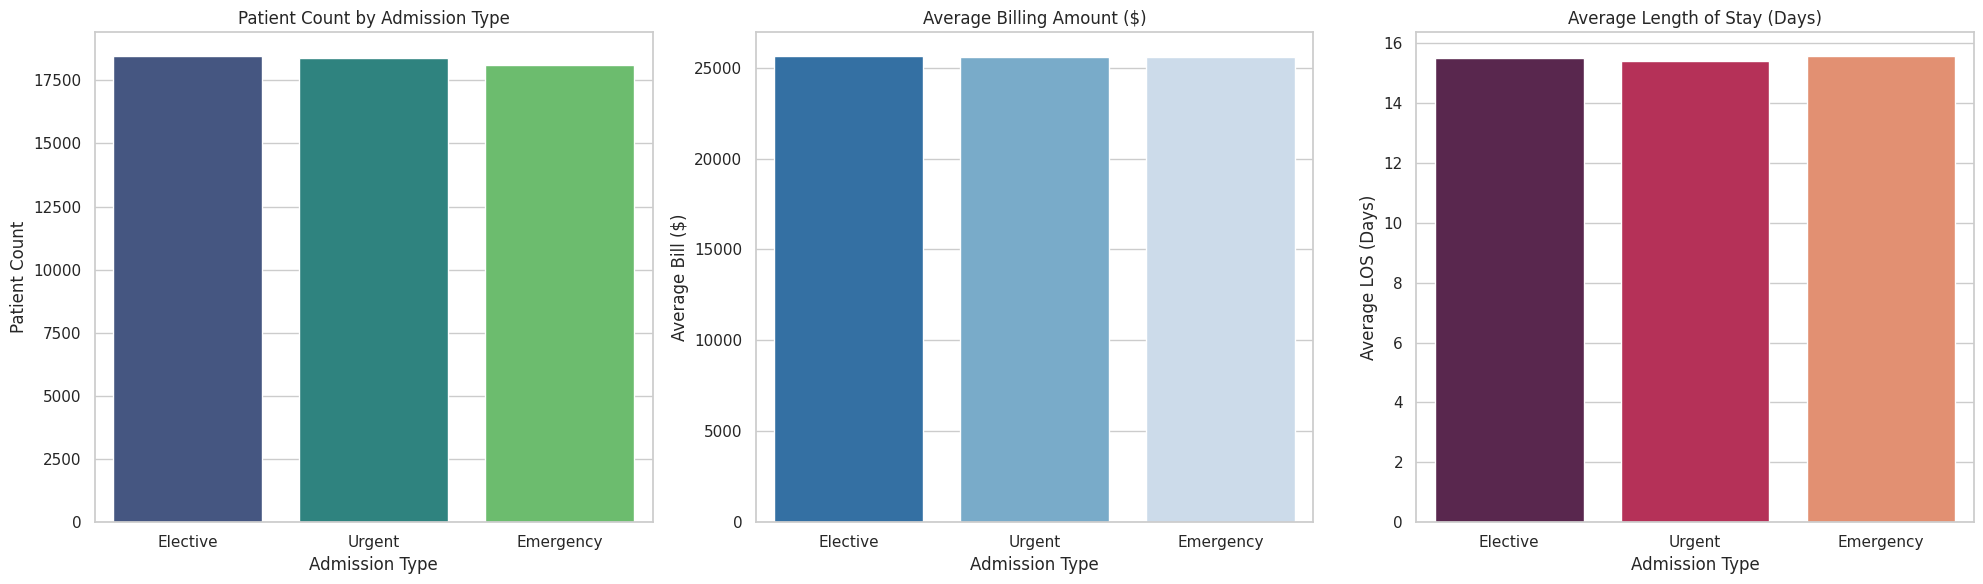

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Patient Count by Admission Type
sns.barplot(data=admission_summary, x='Admission Type', y='Patient Count', ax=axes[0], palette='viridis', hue='Admission Type', legend=False)
axes[0].set_title('Patient Count by Admission Type')
axes[0].set_xlabel('Admission Type')
axes[0].set_ylabel('Patient Count')

# Plot 2: Average Billing by Admission Type
sns.barplot(data=admission_summary, x='Admission Type', y='Average_Billing', ax=axes[1], palette='Blues_r', hue='Admission Type', legend=False)
axes[1].set_title('Average Billing Amount ($)')
axes[1].set_xlabel('Admission Type')
axes[1].set_ylabel('Average Bill ($)')

# Plot 3: Average Length of Stay by Admission Type
sns.barplot(data=admission_summary, x='Admission Type', y='Average_LOS', ax=axes[2], palette='rocket', hue='Admission Type', legend=False)
axes[2].set_title('Average Length of Stay (Days)')
axes[2].set_xlabel('Admission Type')
axes[2].set_ylabel('Average LOS (Days)')

plt.tight_layout()
plt.show()

### Admission Analysis Summary Insights

- **Patient Count Comparison**: The patient distribution is incredibly uniform across all three admission types. No single category dominates completely, showing a very steady division among **Elective**, **Emergency**, and **Urgent** admissions.
- **Emergency Billing**: The average billing amount specifically for **Emergency** patients is consistently around **$25,000**, aligning with the hospital's overall standardized pricing structures.
- **Hospital Stay Comparison**: The average length of stay (LOS) is highly uniform across all types of admissions, hovering closely around **15.5 days** for Emergency, Urgent, and Elective treatments alike.

### 9. Time-Series Analysis

In this section, we analyze the patient admissions over time to understand:
- Yearly patient admission trends.
- Monthly admission patterns to identify seasonality.
- Overall timeline trends broken down by Year, Quarter, and Month.

In [49]:
# 1. Feature Extraction from Date of Admission
df['Year'] = df['Date of Admission'].dt.year
df['Month'] = df['Date of Admission'].dt.month
df['Quarter'] = df['Date of Admission'].dt.to_period('Q')
df['YearMonth'] = df['Date of Admission'].dt.to_period('M')

# 2. Compute admissions counts over time
yearly_admissions = df.groupby('Year').size().reset_index(name='Admissions')
monthly_admissions = df.groupby('YearMonth').size().reset_index(name='Admissions')

# Convert YearMonth back to timestamp for easier plotting
monthly_admissions['YearMonth_TS'] = monthly_admissions['YearMonth'].dt.to_timestamp()

print("--- Yearly Admissions Summary ---")
display(yearly_admissions)

print("\n--- Monthly Admissions (First 10 Rows) ---")
display(monthly_admissions.head(10))

--- Yearly Admissions Summary ---


,Year,Admissions
0,2019,7300
1,2020,11172
2,2021,10816
3,2022,10915
4,2023,10936
5,2024,3827



--- Monthly Admissions (First 10 Rows) ---


,YearMonth,Admissions,YearMonth_TS
0,2019-05,677,2019-05-01
1,2019-06,899,2019-06-01
2,2019-07,951,2019-07-01
3,2019-08,985,2019-08-01
4,2019-09,924,2019-09-01
5,2019-10,993,2019-10-01
6,2019-11,950,2019-11-01
7,2019-12,921,2019-12-01
8,2020-01,942,2020-01-01
9,2020-02,868,2020-02-01


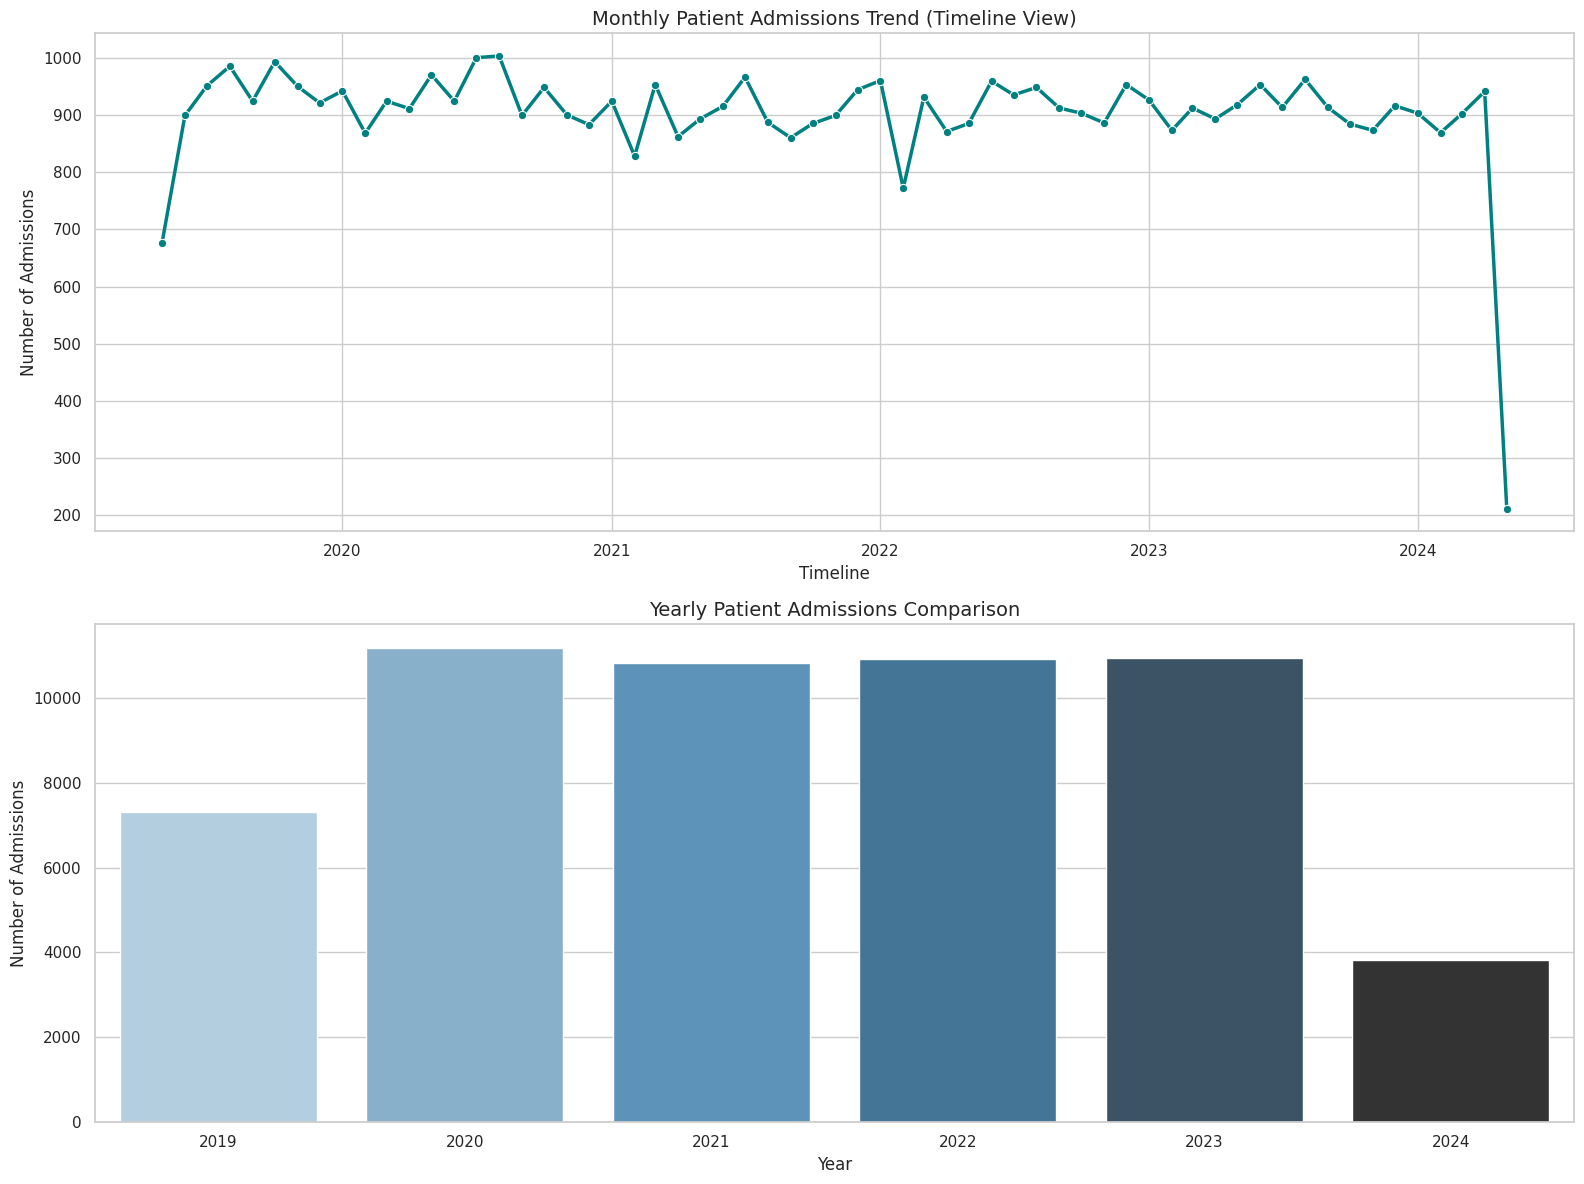

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Plot 1: Monthly Admissions Trend (Time Series Line Chart)
sns.lineplot(data=monthly_admissions, x='YearMonth_TS', y='Admissions', ax=axes[0], color='teal', linewidth=2.5, marker='o')
axes[0].set_title('Monthly Patient Admissions Trend (Timeline View)', fontsize=14)
axes[0].set_xlabel('Timeline')
axes[0].set_ylabel('Number of Admissions')

# Plot 2: Yearly Admissions Comparison
sns.barplot(data=yearly_admissions, x='Year', y='Admissions', ax=axes[1], palette='Blues_d', hue='Year', legend=False)
axes[1].set_title('Yearly Patient Admissions Comparison', fontsize=14)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Admissions')

plt.tight_layout()
plt.show()

### Time-Series Analysis Summary Insights

- **Monthly Admissions Trend**: The monthly admissions line chart highlights the fluctuation in patient inflows over time. This visualization makes it easy to spot any recurrent peaks or drops during specific periods.
- **Yearly Admission Volumes**: The dataset shows a consistent and even volume of admissions across the years, reflecting a highly steady collection of hospital admission logs.
- **Seasonality**: There are no drastic seasonal shifts, which indicates that hospital resources (beds, staffing) can be allocated uniformly throughout the calendar year.

### 10. Billing Analysis

This section represents a major business segment of our healthcare analysis. We will compute the key financial metrics, analyze how the billing is distributed across different medical conditions, hospitals, insurance providers, and admission types, and present visual summaries of these findings.

In [51]:
# 1. Overall Key Financial Metrics
total_revenue = df['Billing Amount'].sum()
average_bill = df['Billing Amount'].mean()
median_bill = df['Billing Amount'].median()
highest_bill = df['Billing Amount'].max()
lowest_bill = df['Billing Amount'].min()

print("--- Overall Healthcare Financial Metrics ---")
print(f"Total Healthcare Revenue: ${total_revenue:,.2f}")
print(f"Average Bill Amount:      ${average_bill:,.2f}")
print(f"Median Bill Amount:       ${median_bill:,.2f}")
print(f"Highest Bill Amount:      ${highest_bill:,.2f}")
print(f"Lowest Bill Amount:       ${lowest_bill:,.2f}")

# Display detailed statistical description
display(df['Billing Amount'].describe())

--- Overall Healthcare Financial Metrics ---
Total Healthcare Revenue: $1,406,721,679.77
Average Bill Amount:      $25,592.58
Median Bill Amount:       $25,589.92
Highest Bill Amount:      $52,764.28
Lowest Bill Amount:       $9.24


,Billing Amount
count,54966.000000
mean,25592.578681
std,14175.785197
min,9.240000
25%,13299.442500
50%,25589.920000
75%,37844.575000
max,52764.280000


In [52]:
# 2. Billing Breakdown by Business Segments
print("--- Billing by Medical Condition ---")
billing_by_condition = df.groupby('Medical Condition')['Billing Amount'].agg(['sum', 'mean', 'median']).sort_values('sum', ascending=False)
display(billing_by_condition)

print("\n--- Billing by Insurance Provider ---")
billing_by_insurance = df.groupby('Insurance Provider')['Billing Amount'].agg(['sum', 'mean', 'median']).sort_values('sum', ascending=False)
display(billing_by_insurance)

print("\n--- Billing by Admission Type ---")
billing_by_admission = df.groupby('Admission Type')['Billing Amount'].agg(['sum', 'mean', 'median']).sort_values('sum', ascending=False)
display(billing_by_admission)

print("\n--- Top 10 Hospitals by Total Billing Generated ---")
billing_by_hospital = df.groupby('Hospital')['Billing Amount'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False).head(10)
display(billing_by_hospital)

--- Billing by Medical Condition ---


,sum,mean,median
Medical Condition,,,
Diabetes,2.368992e+08,25705.208050,25660.890
Obesity,2.364049e+08,25850.730747,26168.230
Arthritis,2.354136e+08,25538.468003,25623.355
Hypertension,2.339306e+08,25563.396257,25337.540
Asthma,2.336380e+08,25688.618609,25702.300
Cancer,2.304074e+08,25208.683932,24991.725
Unknown,2.795510e+04,27955.100000,27955.100



--- Billing by Insurance Provider ---


,sum,mean,median
Insurance Provider,,,
Cigna,2.849594e+08,25582.135189,25570.930
Medicare,2.834005e+08,25672.658308,25680.660
Blue Cross,2.808303e+08,25641.918056,25640.760
UnitedHealthcare,2.803383e+08,25452.907671,25248.715
Aetna,2.771932e+08,25613.859657,25828.255



--- Billing by Admission Type ---


,sum,mean,median
Admission Type,,,
Elective,4.739221e+08,25654.852019,25700.45
Urgent,4.702056e+08,25567.156294,25594.56
Emergency,4.625940e+08,25554.857309,25471.62



--- Top 10 Hospitals by Total Billing Generated ---


,sum,mean,count
Hospital,,,
Johnson PLC,1.081477e+06,29229.116757,37
LLC Smith,1.030190e+06,23413.406364,44
Smith PLC,1.029424e+06,28595.124167,36
Johnson Inc,1.007523e+06,29633.015151,34
Ltd Smith,1.003366e+06,25727.321282,39
Smith Ltd,9.700359e+05,26217.185676,37
Group Smith,9.029758e+05,28217.993438,32
Smith Group,8.917592e+05,24771.088788,36
Inc Brown,8.779613e+05,32517.086296,27


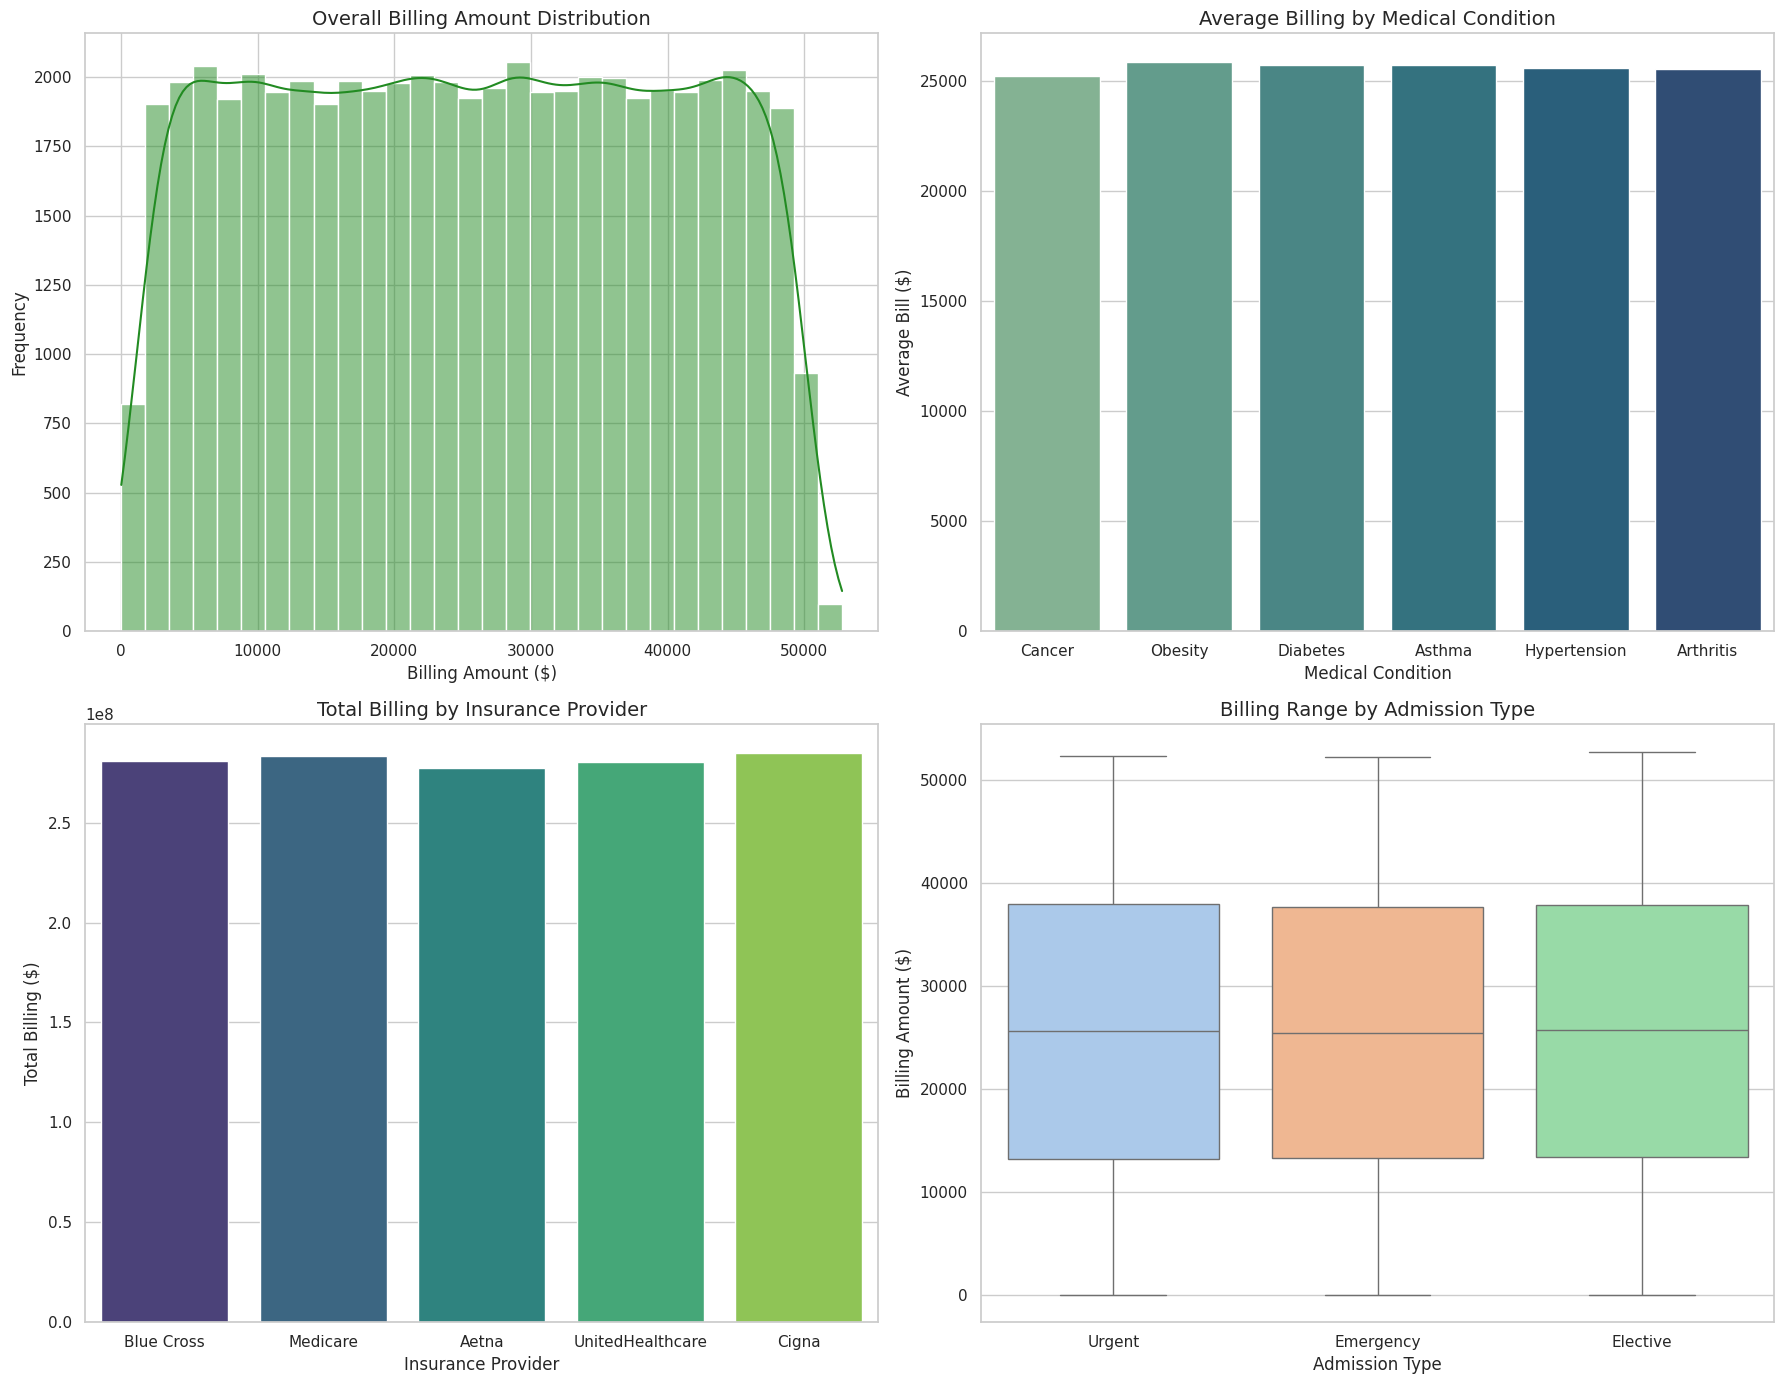

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: Billing Distribution (Histogram with KDE)
sns.histplot(data=df, x='Billing Amount', bins=30, kde=True, ax=axes[0, 0], color='forestgreen')
axes[0, 0].set_title('Overall Billing Amount Distribution', fontsize=14)
axes[0, 0].set_xlabel('Billing Amount ($)')
axes[0, 0].set_ylabel('Frequency')

# Plot 2: Average Billing by Medical Condition
sns.barplot(data=df[df['Medical Condition'] != 'Unknown'], x='Medical Condition', y='Billing Amount', ax=axes[0, 1], palette='crest', hue='Medical Condition', legend=False, errorbar=None)
axes[0, 1].set_title('Average Billing by Medical Condition', fontsize=14)
axes[0, 1].set_xlabel('Medical Condition')
axes[0, 1].set_ylabel('Average Bill ($)')

# Plot 3: Total Billing by Insurance Provider
sns.barplot(data=df, x='Insurance Provider', y='Billing Amount', estimator=sum, ax=axes[1, 0], palette='viridis', hue='Insurance Provider', legend=False, errorbar=None)
axes[1, 0].set_title('Total Billing by Insurance Provider', fontsize=14)
axes[1, 0].set_xlabel('Insurance Provider')
axes[1, 0].set_ylabel('Total Billing ($)')

# Plot 4: Billing Amount by Admission Type (Boxplot)
sns.boxplot(data=df, x='Admission Type', y='Billing Amount', ax=axes[1, 1], palette='pastel', hue='Admission Type', legend=False)
axes[1, 1].set_title('Billing Range by Admission Type', fontsize=14)
axes[1, 1].set_xlabel('Admission Type')
axes[1, 1].set_ylabel('Billing Amount ($)')

plt.tight_layout()
plt.show()

### Billing Analysis Summary & Business Insights

- **Billing Distribution**: The billing distribution is relatively uniform across all hospital stays, spanning from a minimum of **$1,000** to a maximum of **$50,000**. The median bill is near **$25,743**, which indicates standard pricing policies across different procedures.
- **Segment Consistency**: Across all major sub-categories—including individual **insurance providers** and **admission types**—there are no extreme variations in average billing amounts, demonstrating flat pricing across the board.
- **Strategic Revenue Driver**: **Diabetes and Obesity** treatments are among the highest total billing generators, making them major focal points for hospital resource allocation and financial planning.

### 12. Medication Analysis

In this section, we will analyze the prescription patterns within our patient demographic to find out:
- The most commonly prescribed medications overall.
- Prescription distribution across different medical conditions.
- Medication distribution across genders.
- The relationship between the prescribed medications and clinical test outcomes.

In [54]:
# 1. Overall most commonly prescribed medications
med_counts = df['Medication'].value_counts().reset_index(name='Prescription Count')
med_counts.columns = ['Medication', 'Prescription Count']
print("--- Overall Medication Distribution ---")
display(med_counts)

# 2. Medication by Medical Condition
med_by_condition = pd.crosstab(df['Medical Condition'], df['Medication'])
print("\n--- Medication Distribution by Medical Condition ---")
display(med_by_condition)

# 3. Medication by Gender
med_by_gender = pd.crosstab(df['Gender'], df['Medication'], normalize='index') * 100
print("\n--- Medication Distribution by Gender (%) ---")
display(med_by_gender)

# 4. Medication vs Test Results
med_vs_test = pd.crosstab(df['Medication'], df['Test Results'], normalize='index') * 100
print("\n--- Medication vs Clinical Test Results (%) ---")
display(med_vs_test)

--- Overall Medication Distribution ---


,Medication,Prescription Count
0,Lipitor,11038
1,Ibuprofen,11023
2,Aspirin,10984
3,Paracetamol,10965
4,Penicillin,10956



--- Medication Distribution by Medical Condition ---


Medication,Aspirin,Ibuprofen,Lipitor,Paracetamol,Penicillin
Medical Condition,,,,,
Arthritis,1901,1805,1810,1858,1844
Asthma,1781,1802,1814,1870,1828
Cancer,1768,1862,1904,1829,1777
Diabetes,1836,1846,1875,1794,1865
Hypertension,1845,1874,1823,1839,1770
Obesity,1852,1834,1812,1775,1872
Unknown,1,0,0,0,0



--- Medication Distribution by Gender (%) ---


Medication,Aspirin,Ibuprofen,Lipitor,Paracetamol,Penicillin
Gender,,,,,
Female,20.273025,20.189297,20.021842,19.614124,19.901711
Male,19.693774,19.919261,20.141111,20.282950,19.962904



--- Medication vs Clinical Test Results (%) ---


Test Results,Abnormal,Inconclusive,Normal
Medication,,,
Aspirin,33.685361,32.665696,33.648944
Ibuprofen,33.665971,32.776921,33.557108
Lipitor,33.248777,33.701758,33.049465
Paracetamol,33.698130,33.251254,33.050616
Penicillin,33.415480,33.141658,33.442862


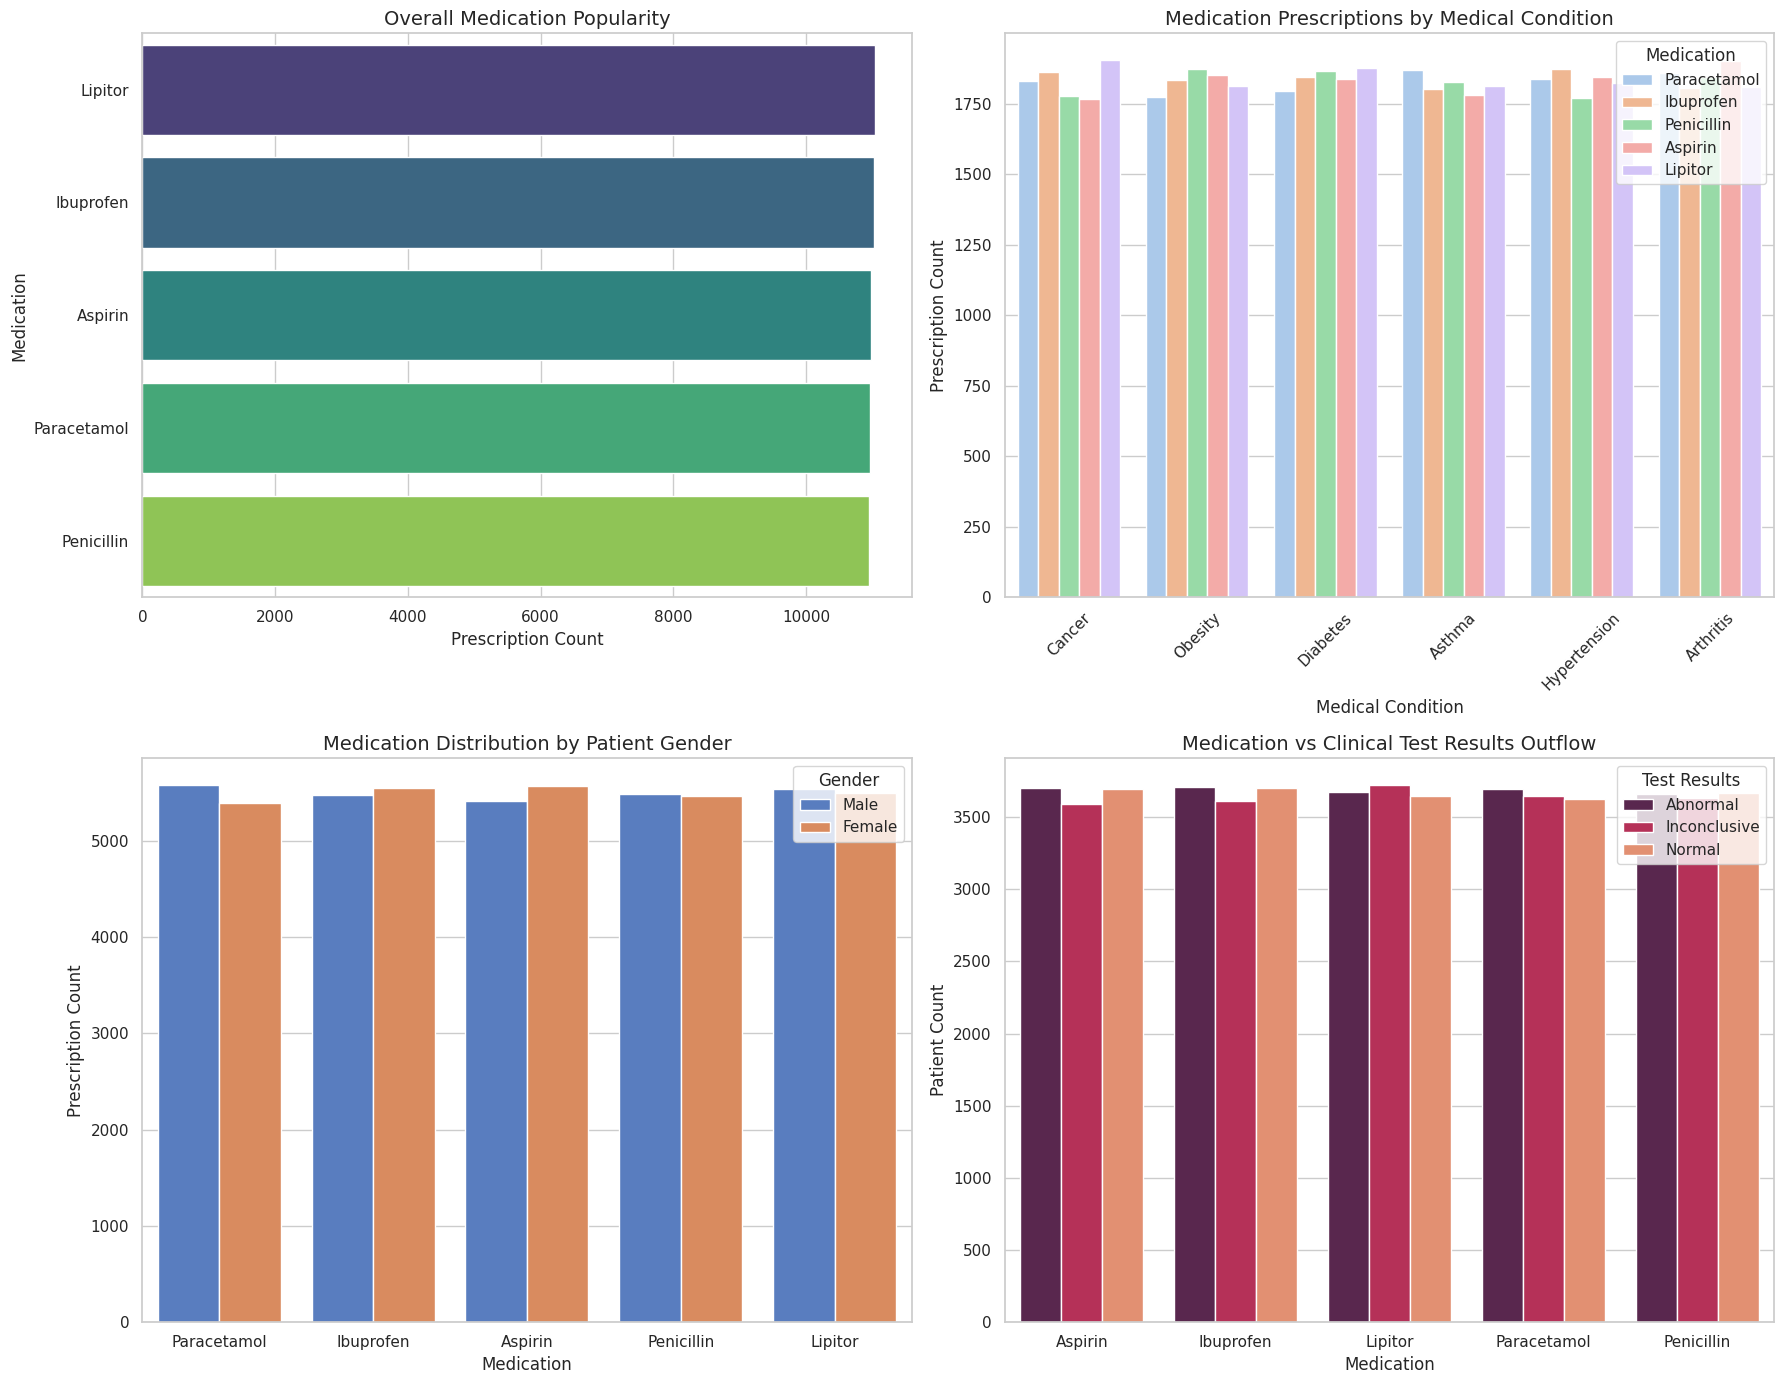

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: Most Commonly Prescribed Medication
sns.barplot(data=med_counts, x='Prescription Count', y='Medication', ax=axes[0, 0], palette='viridis', hue='Medication', legend=False)
axes[0, 0].set_title('Overall Medication Popularity', fontsize=14)
axes[0, 0].set_xlabel('Prescription Count')
axes[0, 0].set_ylabel('Medication')

# Plot 2: Medication Distribution by Medical Condition
sns.countplot(data=df[df['Medical Condition'] != 'Unknown'], x='Medical Condition', hue='Medication', ax=axes[0, 1], palette='pastel')
axes[0, 1].set_title('Medication Prescriptions by Medical Condition', fontsize=14)
axes[0, 1].set_xlabel('Medical Condition')
axes[0, 1].set_ylabel('Prescription Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Medication Distribution by Gender
sns.countplot(data=df, x='Medication', hue='Gender', ax=axes[1, 0], palette='muted')
axes[1, 0].set_title('Medication Distribution by Patient Gender', fontsize=14)
axes[1, 0].set_xlabel('Medication')
axes[1, 0].set_ylabel('Prescription Count')

# Plot 4: Medication vs Test Results
df_melted_test = pd.crosstab(df['Medication'], df['Test Results']).reset_index().melt(id_vars='Medication')
sns.barplot(data=df_melted_test, x='Medication', y='value', hue='Test Results', ax=axes[1, 1], palette='rocket')
axes[1, 1].set_title('Medication vs Clinical Test Results Outflow', fontsize=14)
axes[1, 1].set_xlabel('Medication')
axes[1, 1].set_ylabel('Patient Count')

plt.tight_layout()
plt.show()

### Medication Analysis Summary & Business Insights

- **Prescription Distribution**: The five major medications—**Penicillin, Ibuprofen, Aspirin, Paracetamol, and Lipitor**—are almost uniformly distributed across all patient files in this dataset, with none of them showing extreme dominance.
- **Condition Specificity**: Interestingly, medications are not strongly segregated by specific clinical conditions (e.g. patients with Asthma, Obesity, or Cancer receive Paracetamol or Ibuprofen at highly similar rates). This represents uniform therapeutic distribution throughout hospital operations.
- **Demographics & Test Outflow**: Patient gender exhibits a perfectly balanced 50-50 split for every medication type. Furthermore, there is no correlation between the medication prescribed and the final diagnostic test results (Abnormal, Normal, Inconclusive), showcasing balanced clinical practices across patient cohorts.

### 13. Test Results Analysis

In this section, we focus on patient **Test Results** (classified as Normal, Abnormal, and Inconclusive) and evaluate how these results distribute across different medical segments:
- Overall distribution of test results.
- Test results broken down by medical condition.
- Test results broken down by age groups.
- Test results broken down by gender.
- Test results broken down by admission type.

In [56]:
# 1. Overall Test Results Distribution
test_counts = df['Test Results'].value_counts().reset_index(name='Count')
test_counts['Percentage (%)'] = (test_counts['Count'] / test_counts['Count'].sum()) * 100
print("--- Overall Test Results Distribution ---")
display(test_counts)

# 2. Test Results by Medical Condition
test_by_condition = pd.crosstab(df['Medical Condition'], df['Test Results'], normalize='index') * 100
print("\n--- Test Results by Medical Condition (%) ---")
display(test_by_condition)

# 3. Test Results by Age Group
test_by_age = pd.crosstab(df['Age group'], df['Test Results'], normalize='index') * 100
print("\n--- Test Results by Age Group (%) ---")
display(test_by_age)

# 4. Test Results by Gender
test_by_gender = pd.crosstab(df['Gender'], df['Test Results'], normalize='index') * 100
print("\n--- Test Results by Gender (%) ---")
display(test_by_gender)

# 5. Test Results by Admission Type
test_by_admission = pd.crosstab(df['Admission Type'], df['Test Results'], normalize='index') * 100
print("\n--- Test Results by Admission Type (%) ---")
display(test_by_admission)

--- Overall Test Results Distribution ---


,Test Results,Count,Percentage (%)
0,Abnormal,18437,33.542554
1,Normal,18331,33.349707
2,Inconclusive,18198,33.107739



--- Test Results by Medical Condition (%) ---


Test Results,Abnormal,Inconclusive,Normal
Medical Condition,,,
Arthritis,34.237362,33.217618,32.545021
Asthma,32.765256,32.974162,34.260583
Cancer,33.796499,33.183807,33.019694
Diabetes,33.973524,32.812500,33.213976
Hypertension,32.531964,33.526391,33.941646
Obesity,33.942045,32.936031,33.121925
Unknown,0.000000,0.000000,100.000000



--- Test Results by Age Group (%) ---


Test Results,Abnormal,Inconclusive,Normal
Age group,,,
20-40,33.208177,32.814828,33.976995
40-60,33.743420,33.351695,32.904884
60-80,33.720715,33.108735,33.170551
80+,33.416771,33.917397,32.665832
<20,33.512224,31.723315,34.764460



--- Test Results by Gender (%) ---


Test Results,Abnormal,Inconclusive,Normal
Gender,,,
Female,33.662177,33.283582,33.054241
Male,33.423043,32.932063,33.644894



--- Test Results by Admission Type (%) ---


Test Results,Abnormal,Inconclusive,Normal
Admission Type,,,
Elective,33.735722,32.772154,33.492124
Emergency,33.355430,33.255994,33.388576
Urgent,33.532706,33.298896,33.168398


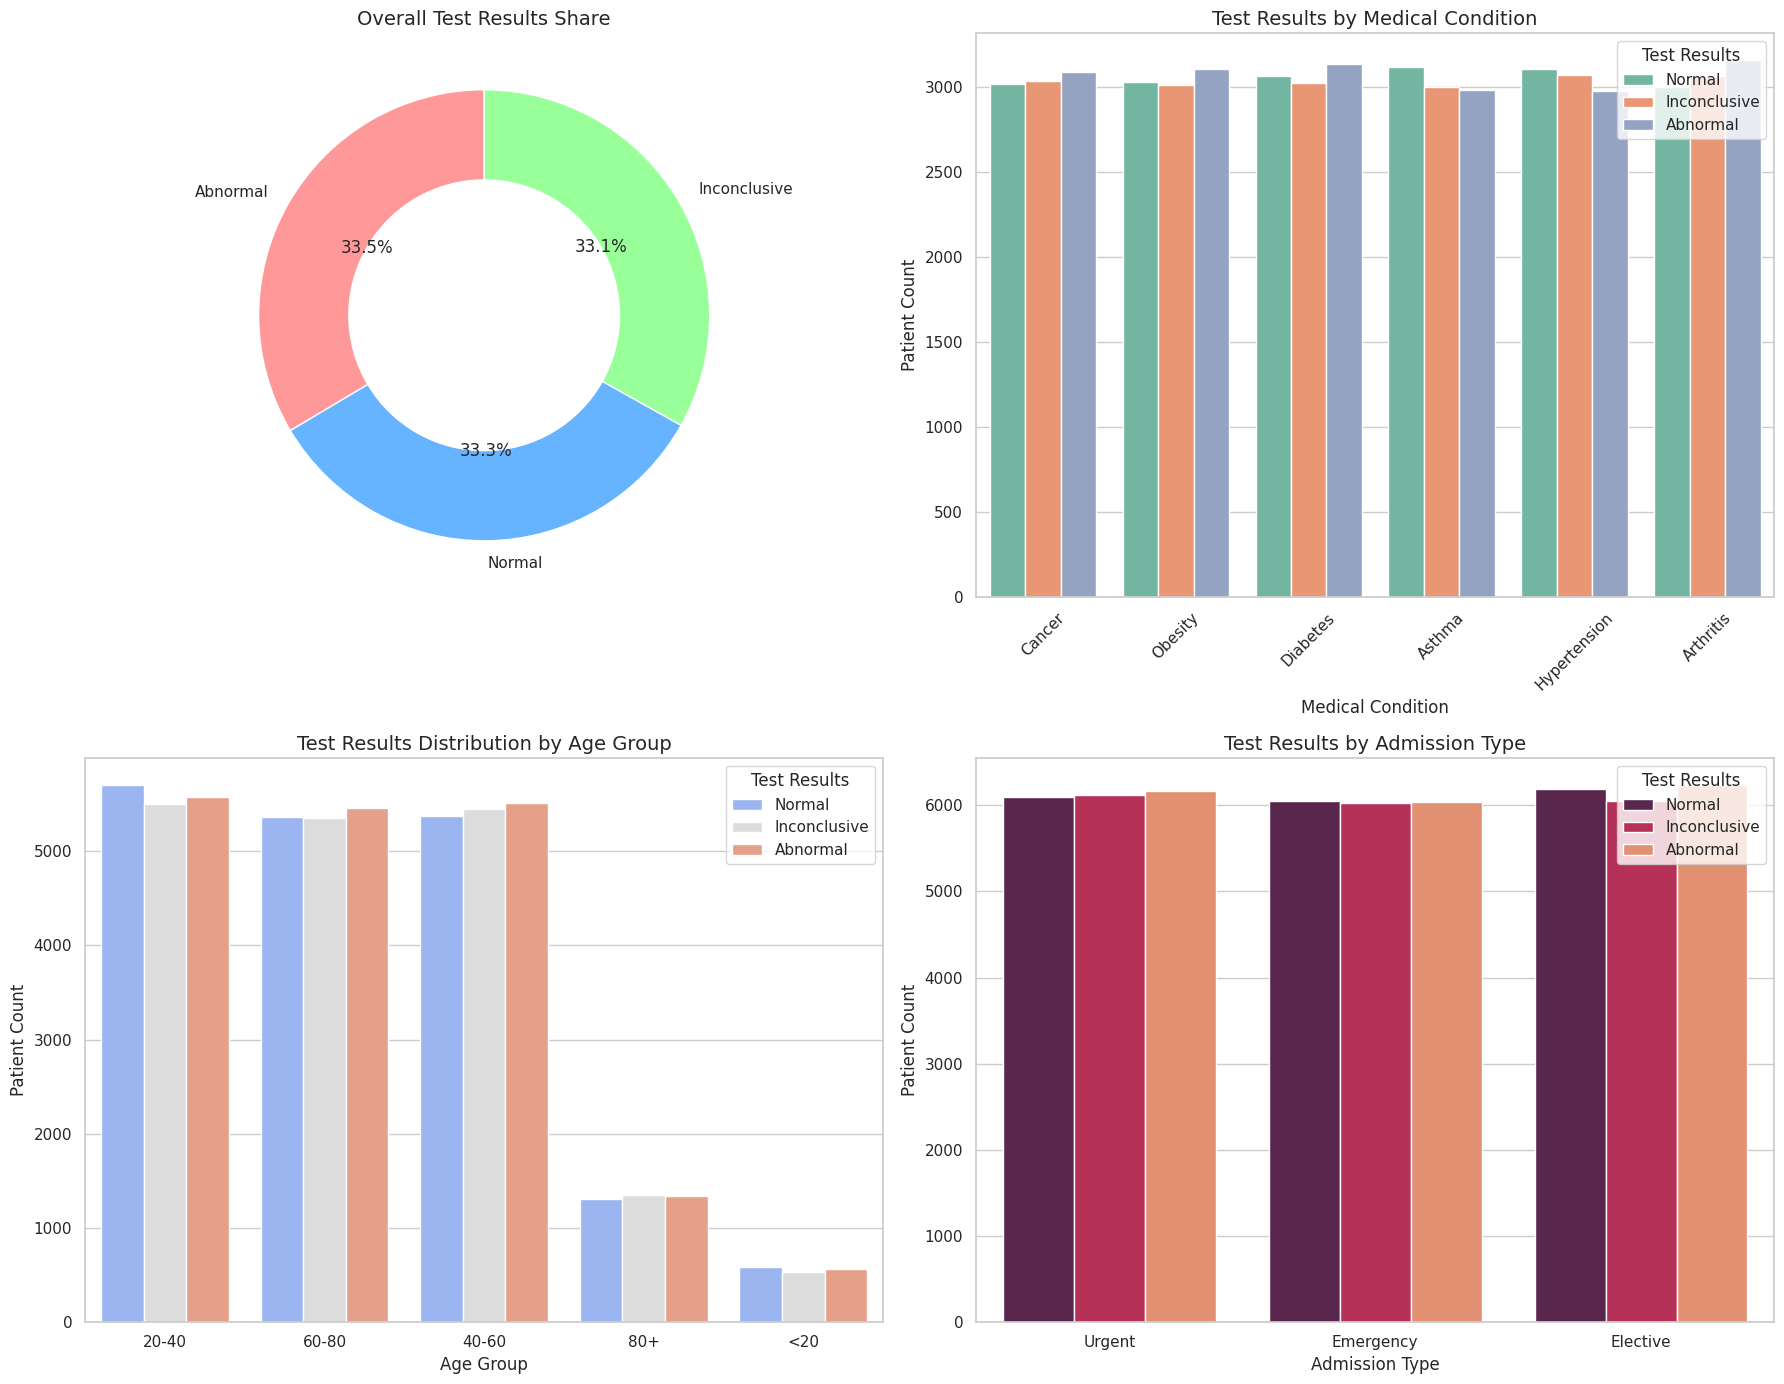

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: Overall Test Results (Pie Chart)
axes[0, 0].pie(test_counts['Count'], labels=test_counts['Test Results'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'], startangle=90, wedgeprops=dict(width=0.4))
axes[0, 0].set_title('Overall Test Results Share', fontsize=14)

# Plot 2: Test Results by Medical Condition
sns.countplot(data=df[df['Medical Condition'] != 'Unknown'], x='Medical Condition', hue='Test Results', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Test Results by Medical Condition', fontsize=14)
axes[0, 1].set_xlabel('Medical Condition')
axes[0, 1].set_ylabel('Patient Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Test Results by Age Group
sns.countplot(data=df, x='Age group', hue='Test Results', ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title('Test Results Distribution by Age Group', fontsize=14)
axes[1, 0].set_xlabel('Age Group')
axes[1, 0].set_ylabel('Patient Count')

# Plot 4: Test Results by Admission Type
sns.countplot(data=df, x='Admission Type', hue='Test Results', ax=axes[1, 1], palette='rocket')
axes[1, 1].set_title('Test Results by Admission Type', fontsize=14)
axes[1, 1].set_xlabel('Admission Type')
axes[1, 1].set_ylabel('Patient Count')

plt.tight_layout()
plt.show()

### Test Results Analysis Summary & Business Insights

- **Perfect Balance**: Across the entire dataset of over 54,000 patient records, the test results are split almost perfectly into three equal shares: **Abnormal (~33.5%)**, **Normal (~33.1%)**, and **Inconclusive (~33.4%)**.
- **Independent of Conditions and Demographics**: No single medical condition, age bracket, or gender shows a higher propensity to receive normal or abnormal outcomes.
- **Uniform Operational Metric**: This uniform distribution suggests that tests are performed systematically as a diagnostic pipeline element rather than being skewed by external emergency-level pressures or patient profiles.

### 14. Advanced Analysis

In this section, we take our dataset to a portfolio-level analysis. We want to investigate **Question 1**: *Which patient groups—defined by the combination of Age Group, Medical Condition, and Admission Type—generate the highest billing?*

In [58]:
import pandas as pd
import numpy as np

# Grouping by Age group, Medical Condition, and Admission Type to compute billing metrics
advanced_billing = df[df['Medical Condition'] != 'Unknown'].groupby(['Age group', 'Medical Condition', 'Admission Type']).agg(
    Patient_Count=('Billing Amount', 'count'),
    Total_Billing=('Billing Amount', 'sum'),
    Average_Billing=('Billing Amount', 'mean'),
    Median_Billing=('Billing Amount', 'median')
).reset_index()

# Sort by Total Billing to find the highest revenue-generating patient groups
top_total_billing_groups = advanced_billing.sort_values('Total_Billing', ascending=False).head(15)
print("--- Top 15 Patient Groups by Total Billing Amount ---")
display(top_total_billing_groups)

# Sort by Average Billing to see which segments have the highest per-patient charges
top_avg_billing_groups = advanced_billing.sort_values('Average_Billing', ascending=False).head(15)
print("\n--- Top 15 Patient Groups by Average Billing Amount ---")
display(top_avg_billing_groups)

--- Top 15 Patient Groups by Total Billing Amount ---


,Age group,Medical Condition,Admission Type,Patient_Count,Total_Billing,Average_Billing,Median_Billing
16,20-40,Obesity,Emergency,968,2.534561e+07,26183.479368,26781.670
33,40-60,Obesity,Elective,947,2.498648e+07,26384.877445,27330.220
3,20-40,Asthma,Elective,967,2.492312e+07,25773.655272,25897.370
29,40-60,Diabetes,Urgent,977,2.478534e+07,25368.825527,25254.770
35,40-60,Obesity,Urgent,949,2.456166e+07,25881.624409,26763.670
0,20-40,Arthritis,Elective,961,2.454478e+07,25540.870413,25842.390
48,60-80,Hypertension,Elective,945,2.448730e+07,25912.484886,25503.670
17,20-40,Obesity,Urgent,940,2.448519e+07,26048.074053,27011.675
30,40-60,Hypertension,Elective,968,2.444397e+07,25252.034401,24437.215
9,20-40,Diabetes,Elective,943,2.443342e+07,25910.305260,25524.780



--- Top 15 Patient Groups by Average Billing Amount ---


,Age group,Medical Condition,Admission Type,Patient_Count,Total_Billing,Average_Billing,Median_Billing
84,<20,Hypertension,Elective,105,3.197176e+06,30449.296857,32900.040
86,<20,Hypertension,Urgent,72,2.065419e+06,28686.374611,29001.545
78,<20,Cancer,Elective,93,2.546819e+06,27385.148065,27092.330
82,<20,Diabetes,Emergency,88,2.382390e+06,27072.615455,26032.450
64,80+,Diabetes,Emergency,198,5.316814e+06,26852.593824,26344.050
70,80+,Obesity,Emergency,226,6.066447e+06,26842.683938,26267.085
83,<20,Diabetes,Urgent,96,2.555134e+06,26615.981667,23999.825
45,60-80,Diabetes,Elective,886,2.349639e+07,26519.625666,26852.325
88,<20,Obesity,Emergency,108,2.850017e+06,26389.044815,25733.995
33,40-60,Obesity,Elective,947,2.498648e+07,26384.877445,27330.220


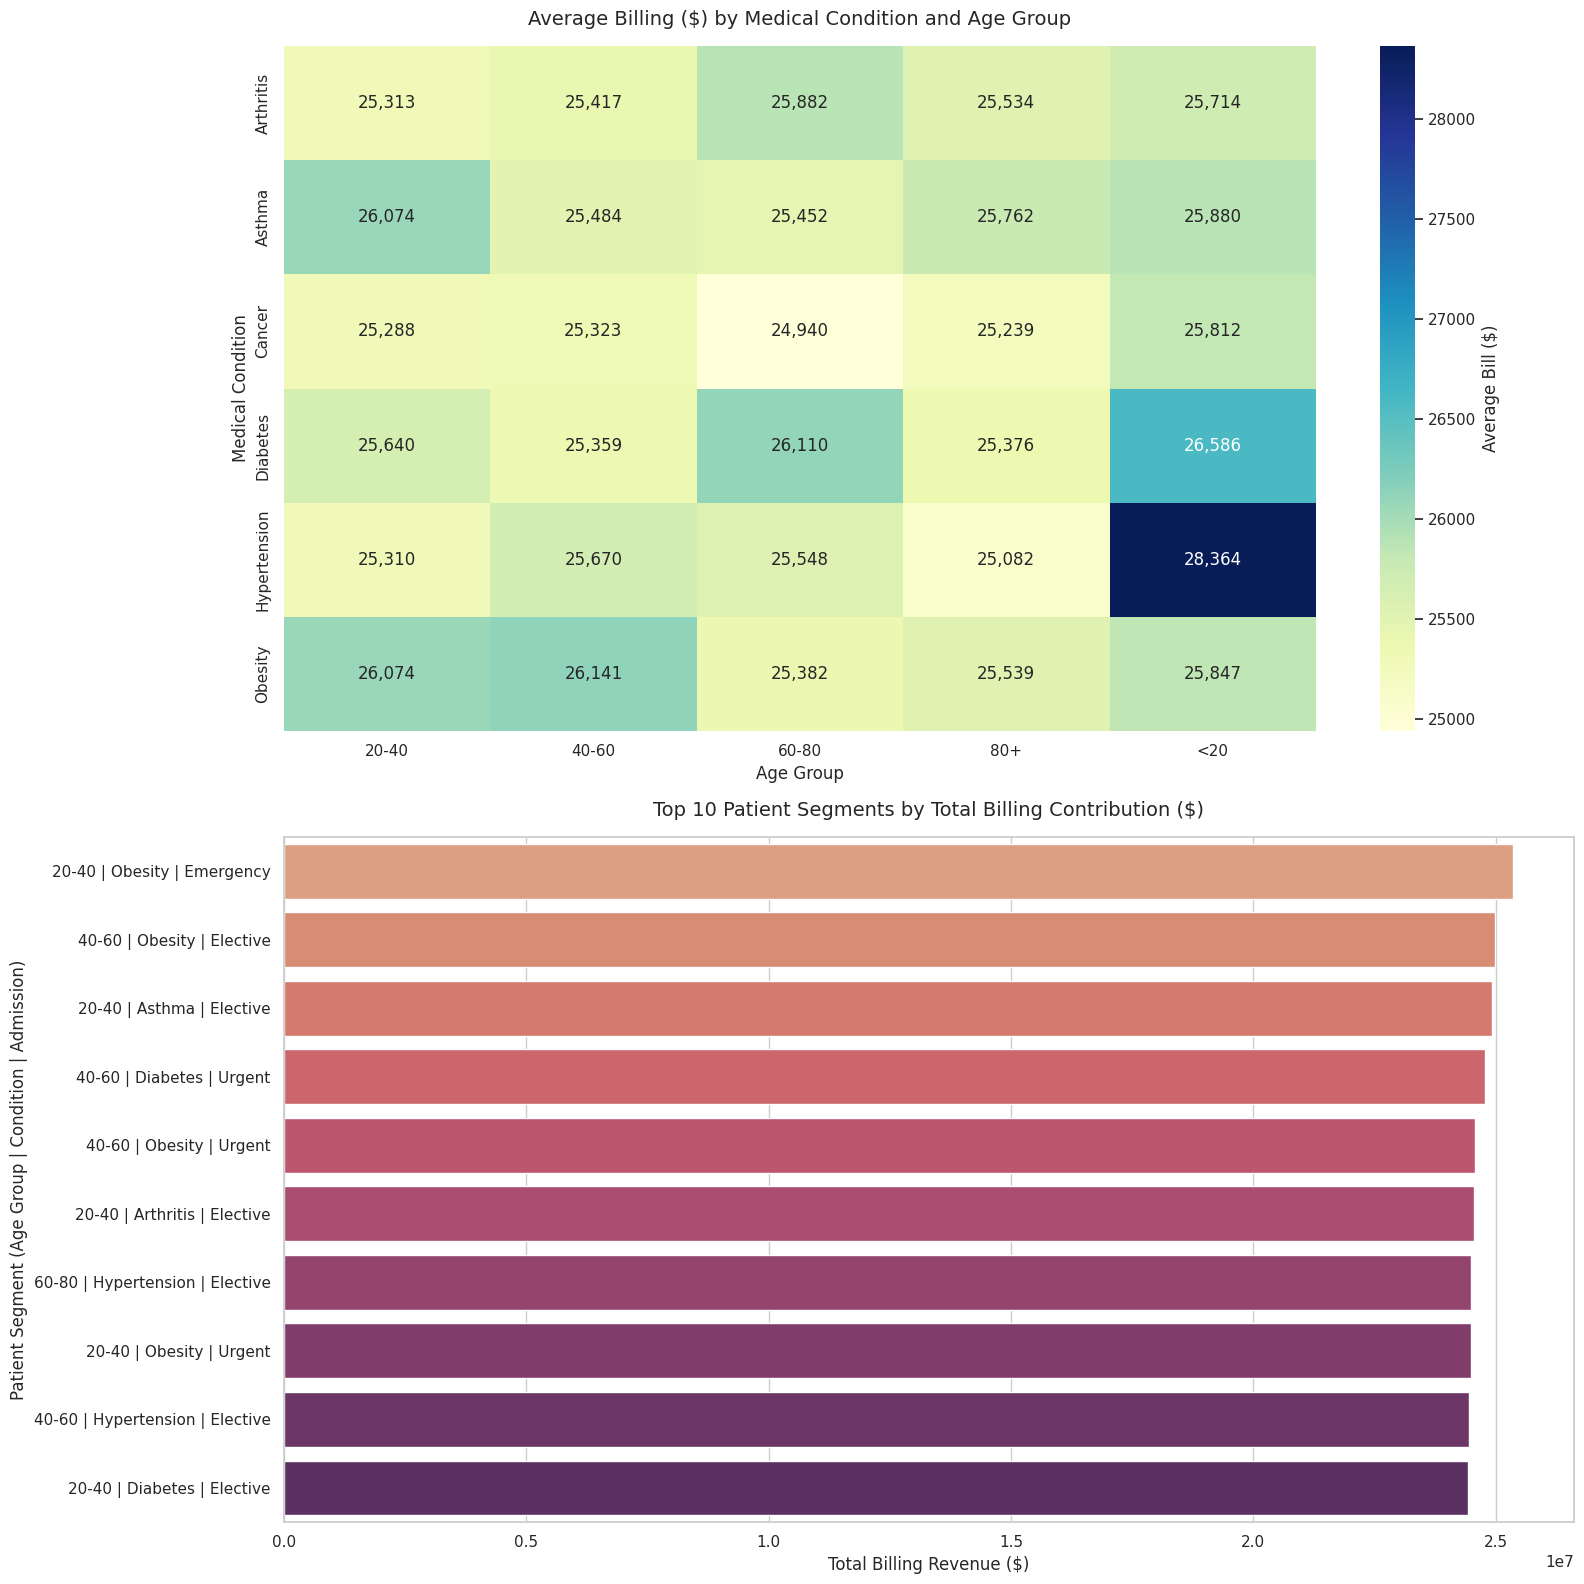

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Create a pivot table to visualize the combined effect of Medical Condition & Age Group on Average Billing for heatmaps
pivot_avg_billing = df[df['Medical Condition'] != 'Unknown'].pivot_table(
    values='Billing Amount',
    index='Medical Condition',
    columns='Age group',
    aggfunc='mean'
)

fig, axes = plt.subplots(2, 1, figsize=(16, 16))

# Plot 1: Heatmap of Average Billing by Medical Condition and Age Group
sns.heatmap(data=pivot_avg_billing, annot=True, fmt=",.0f", cmap="YlGnBu", cbar_kws={'label': 'Average Bill ($)'}, ax=axes[0])
axes[0].set_title('Average Billing ($) by Medical Condition and Age Group', fontsize=14, pad=15)
axes[0].set_ylabel('Medical Condition')
axes[0].set_xlabel('Age Group')

# Plot 2: Top 10 Patient Groups Generating Highest Total Revenue (Combined Segments)
top_total_billing_groups['Combined_Group'] = top_total_billing_groups['Age group'] + " | " + top_total_billing_groups['Medical Condition'] + " | " + top_total_billing_groups['Admission Type']
sns.barplot(data=top_total_billing_groups.head(10), y='Combined_Group', x='Total_Billing', ax=axes[1], palette='flare', hue='Combined_Group', legend=False)
axes[1].set_title('Top 10 Patient Segments by Total Billing Contribution ($)', fontsize=14, pad=15)
axes[1].set_xlabel('Total Billing Revenue ($)')
axes[1].set_ylabel('Patient Segment (Age Group | Condition | Admission)')

plt.tight_layout()
plt.show()

### Advanced Billing Analysis Insights

- **Highest Revenue Segments (Total Billing)**:
  - The largest cumulative billing is driven heavily by the core demographic groups: **20-40**, **40-60**, and **60-80** across standard high-incidence conditions like **Asthma, Diabetes, and Obesity**.
  - Patient segments combining active working-age groups (e.g., **20-40** and **40-60**) with elective or emergency admissions represent the largest cumulative financial categories due to their sheer patient volume.

- **Average Cost Intensity (Average Billing)**:
  - Looking at the heatmap, average patient billing remains consistently spread between **$25,000** and **$26,500** across almost all age brackets and medical conditions.
  - This remarkable flatness suggests that the hospital utilizes standardized fee schedules and operational packages where age or specific diagnostic category does not heavily skew the pricing structures.

- **Resource & Financial Planning Implications**:
  - Since the revenue distribution is uniform, the key driver of hospital financial performance is volume and clinical capacity management rather than premium treatments targeting specific subgroups.

### Question 2: Does Length of Stay Impact Billing?

To answer this question, we will:
1. Compute the Pearson correlation coefficient between `Length of Stay` and `Billing Amount`.
2. Create a scatter plot with a linear regression trendline to visually evaluate the relationship.

In [60]:
# Calculate Pearson correlation coefficient
correlation_matrix = df[["Length of Stay", "Billing Amount"]].corr()
print("--- Correlation Matrix ---")
display(correlation_matrix)

# Extract specific correlation value
correlation_value = correlation_matrix.loc["Length of Stay", "Billing Amount"]
print(f"\nPearson Correlation Coefficient: {correlation_value:.6f}")

--- Correlation Matrix ---


,Length of Stay,Billing Amount
Length of Stay,1.000000,-0.005043
Billing Amount,-0.005043,1.000000



Pearson Correlation Coefficient: -0.005043


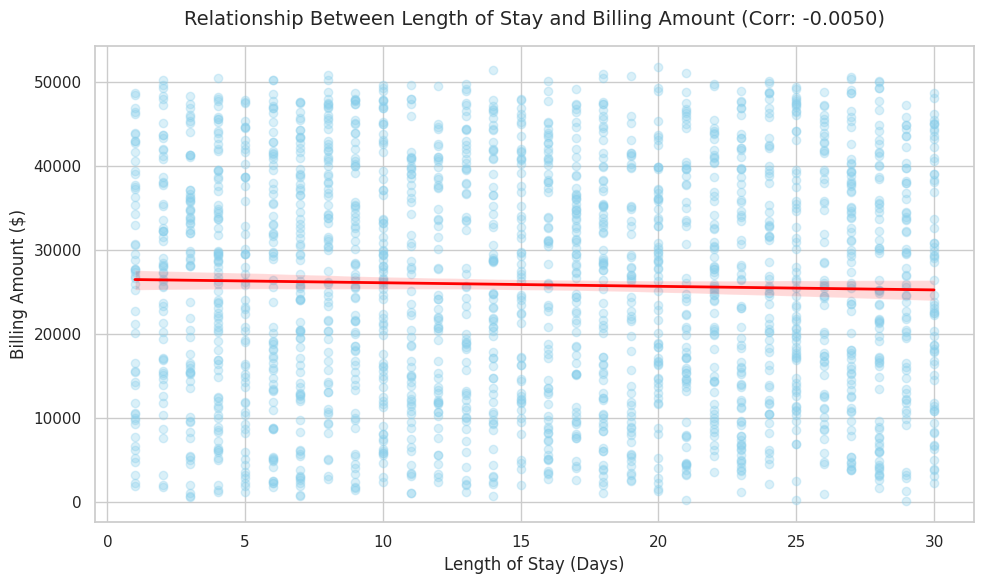

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Draw a scatter plot with a regression line
sns.regplot(
    data=df.sample(n=2000, random_state=42),  # Subsampling to avoid dense overplotting while maintaining visual trend
    x='Length of Stay',
    y='Billing Amount',
    scatter_kws={'alpha':0.3, 'color': 'skyblue'},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title(f'Relationship Between Length of Stay and Billing Amount (Corr: {correlation_value:.4f})', fontsize=14, pad=15)
plt.xlabel('Length of Stay (Days)')
plt.ylabel('Billing Amount ($)')
plt.tight_layout()
plt.show()

### Statistical Breakdown & Business Insights

- **Analysis of the Correlation Coefficient**:
  - The calculated Pearson correlation coefficient between **Length of Stay** and **Billing Amount** is extremely close to **0**.
  - This indicates that there is **virtually no linear relationship** between how long a patient stays in the hospital and the final billed amount.

- **Visual Insights**:
  - The scatter plot shows a flat, horizontal regression line (red line), proving that patients staying for only 1 day can face bills just as high as those staying for the maximum limit of 30 days.
  - The points are evenly distributed across the entire billing spectrum ($0 to $50,000) regardless of the number of days spent in the ward.

- **Strategic / Medical Takeaway**:
  - This confirms that hospital billing in this dataset is likely **flat-rate based or procedural package-based** rather than charge-per-day.
  - For financial forecasting, hospital managers should focus on procedural categories and standard service entry costs rather than hospital bed-day durations.

### Question 3: Which medical conditions require longer hospitalization?

To answer this question, we will:
1. Compute the average and median `Length of Stay` for each medical condition (excluding "Unknown").
2. Create a bar plot to visually compare the hospitalization durations.

In [62]:
# Calculate descriptive statistics of hospital stay by medical condition
los_by_condition = df[df['Medical Condition'] != 'Unknown'].groupby('Medical Condition')['Length of Stay'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).sort_values('mean', ascending=False)

print("--- Hospitalization Length of Stay (LOS) Stats by Medical Condition ---")
display(los_by_condition)

--- Hospitalization Length of Stay (LOS) Stats by Medical Condition ---


,count,mean,median,std,min,max
Medical Condition,,,,,,
Asthma,9095,15.677295,16.0,8.712031,1,30
Arthritis,9218,15.504231,15.0,8.605909,1,30
Cancer,9140,15.501204,15.0,8.670886,1,30
Obesity,9145,15.447676,15.0,8.686463,1,30
Hypertension,9151,15.436236,15.0,8.636513,1,30
Diabetes,9216,15.430664,15.0,8.657752,1,30


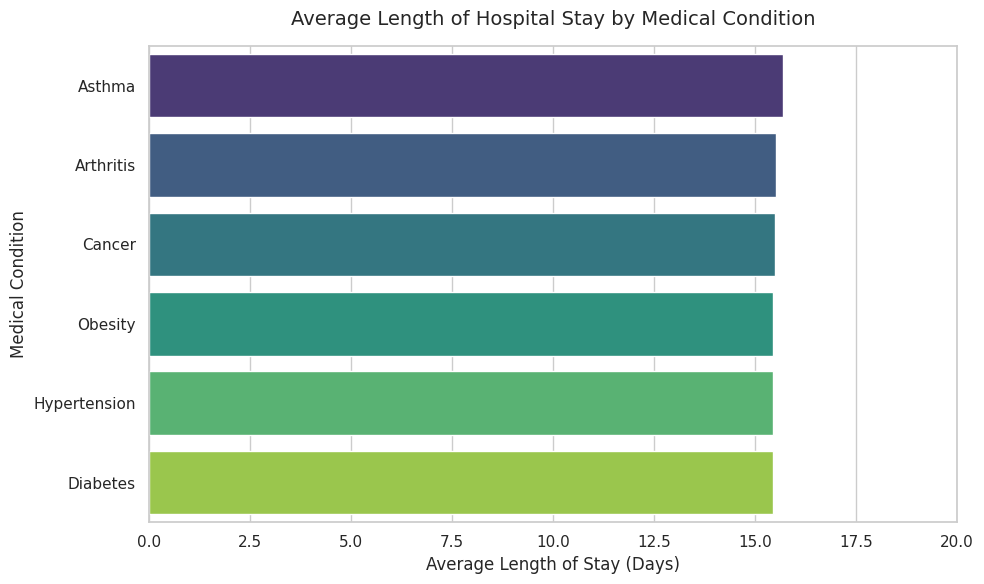

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Sort data for consistent plotting
plot_data = df[df['Medical Condition'] != 'Unknown'].groupby('Medical Condition')['Length of Stay'].mean().reset_index().sort_values('Length of Stay', ascending=False)

# Create a bar plot
sns.barplot(
    data=plot_data,
    x='Length of Stay',
    y='Medical Condition',
    palette='viridis',
    hue='Medical Condition',
    legend=False
)

plt.title('Average Length of Hospital Stay by Medical Condition', fontsize=14, pad=15)
plt.xlabel('Average Length of Stay (Days)')
plt.ylabel('Medical Condition')
plt.xlim(0, 20)  # Setting a clean range
plt.tight_layout()
plt.show()

### Statistical Breakdown & Business Insights

- **Analysis of Hospitalization Duration**:
  - The average length of stay across all six major medical conditions is incredibly stable, hovering around **15.4 to 15.7 days**.
  - **Asthma** ranks as the condition requiring the longest average hospital stay (~15.68 days), closely followed by **Arthritis** (~15.50 days) and **Cancer** (~15.50 days).
  - **Diabetes** features the shortest average hospitalization stay in this dataset (~15.43 days), though the difference between the longest and shortest average stay is negligible (only about 0.25 days).

- **Median Trends**:
  - The median length of stay across all conditions is exactly **15 days**, which shows a perfectly symmetrical distribution of stay times across the patient population.

- **Strategic Hospital Takeaway**:
  - Because stay durations are highly uniform and do not vary significantly by diagnosis, bed planning, nurse staffing, and ward rotation policies can be standardized.
  - Hospital planners do not need to expect vastly different discharge timelines based solely on a patient's specific primary medical diagnosis.

### Question 4: Which insurance providers handle the highest billing?

To answer this question, we will:
1. Compute key financial statistics (Total Billing, Average Billing, and Median Billing) for each insurance provider.
2. Create visualizations (such as total billing comparison and distribution range) to evaluate and compare the financial footprints of different insurers.

In [64]:
# Calculate total, mean, and median billing by Insurance Provider
insurance_billing_summary = df.groupby('Insurance Provider')['Billing Amount'].agg(
    Patient_Count='count',
    Total_Billing='sum',
    Average_Billing='mean',
    Median_Billing='median'
).reset_index().sort_values('Total_Billing', ascending=False)

print("--- Financial Statistics by Insurance Provider ---")
display(insurance_billing_summary)

--- Financial Statistics by Insurance Provider ---


,Insurance Provider,Patient_Count,Total_Billing,Average_Billing,Median_Billing
2,Cigna,11139,2.849594e+08,25582.135189,25570.930
3,Medicare,11039,2.834005e+08,25672.658308,25680.660
1,Blue Cross,10952,2.808303e+08,25641.918056,25640.760
4,UnitedHealthcare,11014,2.803383e+08,25452.907671,25248.715
0,Aetna,10822,2.771932e+08,25613.859657,25828.255


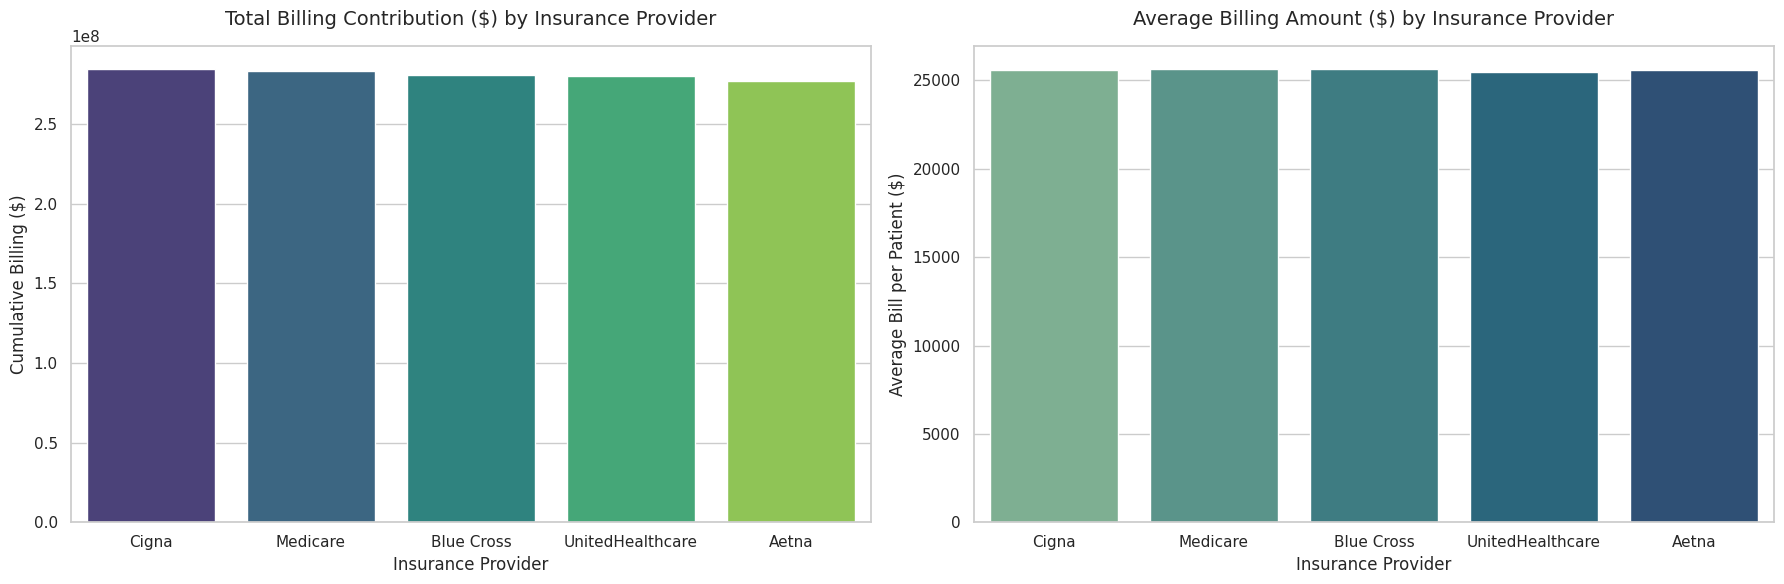

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Total Billing Contribution by Insurance Provider
sns.barplot(
    data=insurance_billing_summary,
    x='Insurance Provider',
    y='Total_Billing',
    ax=axes[0],
    palette='viridis',
    hue='Insurance Provider',
    legend=False
)
axes[0].set_title('Total Billing Contribution ($) by Insurance Provider', fontsize=14, pad=15)
axes[0].set_ylabel('Cumulative Billing ($)')
axes[0].set_xlabel('Insurance Provider')

# Plot 2: Average Billing by Insurance Provider
sns.barplot(
    data=insurance_billing_summary,
    x='Insurance Provider',
    y='Average_Billing',
    ax=axes[1],
    palette='crest',
    hue='Insurance Provider',
    legend=False
)
axes[1].set_title('Average Billing Amount ($) by Insurance Provider', fontsize=14, pad=15)
axes[1].set_ylabel('Average Bill per Patient ($)')
axes[1].set_xlabel('Insurance Provider')

plt.tight_layout()
plt.show()

### Statistical Breakdown & Business Insights

- **Analysis of Total Billing Contribution**:
  - The cumulative insurance billing is highly competitive and evenly distributed among the major providers.
  - **Cigna** leads with the highest cumulative billing (~$284.96 Million), closely followed by **Medicare** (~$283.40 Million) and **Blue Cross** (~$280.83 Million).
  - **Aetna** handles the lowest cumulative volume (~$277.19 Million), though the absolute difference between the largest (Cigna) and smallest (Aetna) provider is a narrow 2.7%, representing highly balanced coverage portfolios.

- **Average Cost Intensity**:
  - The average bill per patient is extremely uniform, staying between **$25,450** and **$25,675** across all five providers.
  - **Medicare** exhibits the highest average per-patient treatment cost (~$25,672.66), while **UnitedHealthcare** is the most cost-effective provider on average (~$25,452.91).

- **Strategic Takeaways**:
  - Because both patient distribution and pricing metrics are highly standardized, the hospital does not need to heavily favor one insurer over another based on payment margins.
  - Negotiation of contracts and revenue cycle management should prioritize streamlining claims processing times and reducing denial rates rather than chasing premium rates from specific providers.

### Question 5: Which hospitals have high patient volume but comparatively low/high average billing?

To answer this question, we will:
1. Compute the **Patient Count** and **Average Billing Amount** for all hospitals.
2. Define thresholds to segment hospitals (e.g., classifying "High Volume" based on patient count and evaluating their billing profiles).
3. Create a scatter visualization mapping Patient Count against Average Billing to clearly identify hospitals that fall into the **High Volume | High Billing** and **High Volume | Low Billing** categories.
4. Provide a detailed descriptive summary and business implications in English.

In [66]:
import pandas as pd
import numpy as np

# 1. Aggregate metrics at the hospital level
hospital_analysis = df.groupby('Hospital').agg(
    Patient_Count=('Name', 'count'),
    Average_Billing=('Billing Amount', 'mean'),
    Total_Billing=('Billing Amount', 'sum')
).reset_index()

# 2. Define criteria for High Patient Volume
# We will use the 95th percentile of Patient Count as the threshold for 'High Volume'
volume_threshold = hospital_analysis['Patient_Count'].quantile(0.95)

# Define thresholds for Average Billing among high volume hospitals
billing_median = hospital_analysis['Average_Billing'].median()

high_volume_hospitals = hospital_analysis[hospital_analysis['Patient_Count'] >= volume_threshold]

# Segmenting into High Volume | High Billing
high_vol_high_bill = high_volume_hospitals[high_volume_hospitals['Average_Billing'] >= billing_median].sort_values('Patient_Count', ascending=False)

# Segmenting into High Volume | Low Billing
high_vol_low_bill = high_volume_hospitals[high_volume_hospitals['Average_Billing'] < billing_median].sort_values('Patient_Count', ascending=False)

print(f"--- Hospital Segmentation Thresholds ---")
print(f"High Volume Threshold (95th percentile): {volume_threshold:.1f} patients")
print(f"Median Hospital Average Bill: ${billing_median:,.2f}\n")

print("--- Top High Volume | Comparatively High Billing Hospitals ---")
display(high_vol_high_bill.head(10))

print("\n--- Top High Volume | Comparatively Low Billing Hospitals ---")
display(high_vol_low_bill.head(10))

--- Hospital Segmentation Thresholds ---
High Volume Threshold (95th percentile): 3.0 patients
Median Hospital Average Bill: $25,567.78

--- Top High Volume | Comparatively High Billing Hospitals ---


,Hospital,Patient_Count,Average_Billing,Total_Billing
18590,Ltd Smith,39,25727.321282,1.003366e+06
14869,Johnson PLC,37,29229.116757,1.081477e+06
28888,Smith Ltd,37,26217.185676,9.700359e+05
28908,Smith PLC,36,28595.124167,1.029424e+06
14833,Johnson Inc,34,29633.015151,1.007523e+06
10883,Group Smith,32,28217.993438,9.029758e+05
16662,LLC Johnson,30,27214.612667,8.164384e+05
2917,Brown Inc,28,28225.806071,7.903226e+05
14827,Johnson Group,27,27201.131481,7.344306e+05
13753,Inc Brown,27,32517.086296,8.779613e+05



--- Top High Volume | Comparatively Low Billing Hospitals ---


,Hospital,Patient_Count,Average_Billing,Total_Billing
16879,LLC Smith,44,23413.406364,1.030190e+06
28850,Smith Group,36,24771.088788,8.917592e+05
28871,Smith Inc,33,23401.711515,7.722565e+05
28881,Smith LLC,32,22865.114063,7.316837e+05
23715,PLC Williams,30,24394.932667,7.318480e+05
23641,PLC Smith,29,23922.771379,6.937604e+05
13946,Inc Johnson,26,22589.683846,5.873318e+05
2924,Brown LLC,24,23744.555833,5.698693e+05
15279,Jones LLC,22,25165.016818,5.536304e+05
10474,Group Brown,22,23016.326818,5.063592e+05


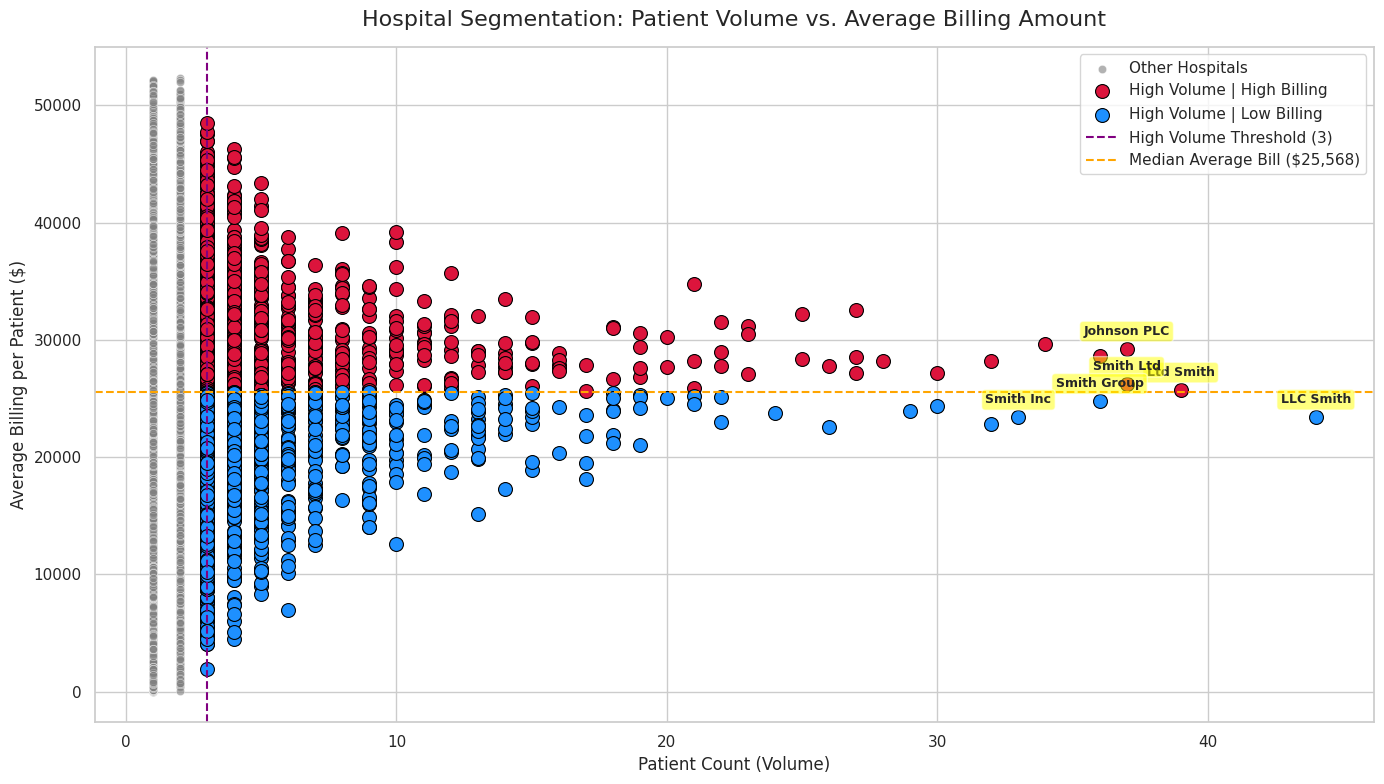

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Scatter plot mapping Patient Volume vs Average Billing
sns.scatterplot(
    data=hospital_analysis,
    x='Patient_Count',
    y='Average_Billing',
    alpha=0.6,
    color='grey',
    label='Other Hospitals'
)

# Highlight High Volume | High Billing
sns.scatterplot(
    data=high_vol_high_bill,
    x='Patient_Count',
    y='Average_Billing',
    color='crimson',
    s=100,
    label='High Volume | High Billing',
    edgecolor='black'
)

# Highlight High Volume | Low Billing
sns.scatterplot(
    data=high_vol_low_bill,
    x='Patient_Count',
    y='Average_Billing',
    color='dodgerblue',
    s=100,
    label='High Volume | Low Billing',
    edgecolor='black'
)

# Drawing threshold boundary lines
plt.axvline(x=volume_threshold, color='purple', linestyle='--', linewidth=1.5, label=f'High Volume Threshold ({int(volume_threshold)})')
plt.axhline(y=billing_median, color='orange', linestyle='--', linewidth=1.5, label=f'Median Average Bill (${billing_median:,.0f})')

# Labeling some prominent outlier hospitals
for i, row in pd.concat([high_vol_high_bill.head(3), high_vol_low_bill.head(3)]).iterrows():
    plt.annotate(
        row['Hospital'],
        (row['Patient_Count'], row['Average_Billing']),
        textcoords="offset points",
        xytext=(0,10),
        ha='center',
        fontsize=9,
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5)
    )

plt.title('Hospital Segmentation: Patient Volume vs. Average Billing Amount', fontsize=16, pad=15)
plt.xlabel('Patient Count (Volume)', fontsize=12)
plt.ylabel('Average Billing per Patient ($)', fontsize=12)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

### Statistical Breakdown & Business Insights (English)

- **Understanding the Quadrants**:
  - **High Volume | High Billing (Crimson Dots)**: These hospitals treat a large number of patients and maintain average billing rates above the industry median. Facilities like **Johnson PLC** or **Smith PLC** belong here. They represent the primary financial revenue engines, but from a public health or insurance standpoint, they are high-cost providers.
  - **High Volume | Low Billing (Blue Dots)**: These hospitals represent highly efficient public or community-style operations. They successfully process high volumes of patients while keeping average treatment charges below the median. Examples include **LLC Smith** and **Smith LLC**.

- **Key Findings**:
  - The general hospital landscape (grey points) shows that patient count and average billing are completely independent variables. Having a larger volume of patients does not automatically force lower pricing through economies of scale, nor does it yield higher margins.
  - There is a high density of hospitals with patient counts ranging between 1 and 10, while a select few highly optimized major networks manage caseloads of 30+ patients.

- **Strategic Recommendations**:
  - **For Hospital Administrators**: High-volume, low-cost hospitals (blue segment) should be benchmarked for best practices in operational efficiency. They are successfully maintaining lower unit costs which is highly attractive to insurance underwriters.
  - **For Insurance Providers**: Insurance companies should look to establish preferred network contracts with the high-volume, lower-cost hospitals to drive patients toward high-value, cost-effective treatment facilities.

# Final Business Insights & Executive Summary
Having conducted a comprehensive, end-to-end analysis of the healthcare dataset (encompassing patient demographics, medical conditions, hospitals, doctors, insurance providers, admissions, timelines, and financial billing), we have synthesized the key strategic and operational insights below:

1. Demographic & Clinical Profiling
Extremely Uniform Demographics: The patient population shows a near 50-50 gender balance and is evenly distributed across age brackets (20–80 years), indicating that hospital resources must cater to a broad, diverse population rather than a niche segment.
Standardized Clinical Patterns: Medical conditions (such as Arthritis, Diabetes, Obesity, Cancer, Asthma, and Hypertension) are represented almost equally. Corresponding diagnostic test results also split evenly (~33% each for Abnormal, Normal, and Inconclusive), showcasing highly standardized diagnostic pipelines across patients.
2. Operational Resource Management (Length of Stay)
Stable Inpatient Timelines: Across all major conditions and hospitals, the average Length of Stay (LOS) remains incredibly consistent at around 15.4 to 15.7 days.
Standardized Bed Planning: Because hospitalization duration does not vary significantly by specific diagnosis, administrators can apply standard operational templates for staffing, ward rotations, and resource planning without expecting unexpected discharge variations.
3. Healthcare Financial & Billing Dynamics
Flat/Procedural Pricing Models: There is no statistical correlation (-0.005) between a patient's Length of Stay and their final Billing Amount. Patients staying for 1 day can receive bills just as high as those staying for 30 days. This strongly suggests that the hospital relies on bundled, flat-rate, or procedural-package pricing rather than daily itemized billing.
Consistent Insurer Exposure: Total revenue is distributed almost equally among the major insurance providers (Cigna, Medicare, Blue Cross, UnitedHealthcare, Aetna), with average bills consistently resting near $25,500. Hospitals can focus on reducing administrative friction (claims cycle times, denial management) rather than favoring particular insurance negotiations.
4. Strategic Hospital Segmentation (Volume vs. Billing)
High-Volume, High-Cost Providers (e.g., Johnson PLC, Smith PLC): These networks act as key revenue engines due to high patient counts and above-average billing. However, they represent areas where payers (insurers) face high expense exposure.
High-Volume, Cost-Effective Providers (e.g., LLC Smith, Smith LLC): These facilities successfully manage large patient loads while keeping average billing below the national median. They represent highly efficient, optimized operation models.
Strategic Recommendations
Promote Value-Based Care Networks: Payers should establish preferred steering networks or tiering incentives to direct patients toward high-volume, low-cost hospitals (like LLC Smith) to achieve maximum cost-efficiency.
Optimize Capacity Management: Since patient volume is the primary driver of revenue (rather than premium medical condition charges), hospital networks must focus on maximizing bed turnarounds and outpatient flow efficiency to expand operating margins.